Optener muestras

In [ ]:
import cv2
import numpy as np
from pathlib import Path

from mmdet.apis import init_detector, inference_detector

# =========================================================
# CONFIG
# =========================================================
CONFIG_PATH = r"C:\workspace\mmdetection\configs\mask2former\mask2former_fruits_r50.py"
# CHECKPOINT_PATH = r"C:\workspace\mmdetection\work_dirs\mask_rcnn_fruits_r50_120e\best_coco_segm_mAP_epoch_20.pth"
CHECKPOINT_PATH = r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\best_coco_segm_mAP_epoch_50.pth"

SRC_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\images\train")
OUT_DIR = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\Imagenes_Output\maskrcnn")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda:0"   # o "cpu"
CONF = 0.80
ALPHA = 0.45
DRAW_BOXES = False
DRAW_LABELS = True

CONTOUR_THICKNESS = 2
TEXT_SCALE = 0.6
TEXT_THICKNESS = 2
TEXT_OUTLINE_THICKNESS = 4

# =========================================================
# CARGAR MODELO
# =========================================================
model = init_detector(CONFIG_PATH, CHECKPOINT_PATH, device=DEVICE)

# Clases desde el modelo/config
if hasattr(model, "dataset_meta") and "classes" in model.dataset_meta:
    CLASSES = model.dataset_meta["classes"]
else:
    # fallback manual por si acaso
    CLASSES = (
        "apple_green",
        "apple_red",
        "peach",
        "orange",
        "pear",
        "avocado",
    )

# Colores BGR (OpenCV)
CLASS_COLORS = {
    "apple_green": (60, 180, 75),
    "apple_red":   (40, 40, 220),
    "peach":       (120, 180, 255),
    "avocado":     (35, 110, 35),
    "pear":        (80, 220, 180),
    "orange":      (0, 140, 255),
}

# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def class_color(cls_id):
    name = CLASSES[int(cls_id)]
    return CLASS_COLORS.get(name, (255, 255, 255))

def darker(color, factor=0.55):
    return tuple(int(ch * factor) for ch in color)

def draw_text_with_outline(img, text, org, color):
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        (0, 0, 0),
        TEXT_OUTLINE_THICKNESS,
        cv2.LINE_AA,
    )
    cv2.putText(
        img, text, org,
        cv2.FONT_HERSHEY_SIMPLEX,
        TEXT_SCALE,
        color,
        TEXT_THICKNESS,
        cv2.LINE_AA,
    )

# =========================================================
# PROCESAR IMÁGENES
# =========================================================
img_paths = sorted([p for p in SRC_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])

saved = 0
skipped = 0

for p in img_paths:
    img_bgr = cv2.imread(str(p))
    if img_bgr is None:
        skipped += 1
        continue

    out = img_bgr.copy()
    H, W = out.shape[:2]

    # Inferencia
    result = inference_detector(model, str(p))

    # pred_instances contiene bboxes, labels, scores, masks
    pred = result.pred_instances

    if pred is not None and len(pred) > 0:
        scores = pred.scores.detach().cpu().numpy()
        keep = scores >= CONF

        if keep.any():
            bboxes = pred.bboxes.detach().cpu().numpy()[keep]
            labels = pred.labels.detach().cpu().numpy()[keep]
            scores = scores[keep]

            masks = None
            if hasattr(pred, "masks") and pred.masks is not None:
                masks = pred.masks.detach().cpu().numpy()[keep]

            overlay = np.zeros((H, W, 3), dtype=np.uint8)
            contour_items = []

            # --- Dibujar máscaras ---
            if masks is not None:
                for i in range(len(labels)):
                    color = class_color(labels[i])

                    m = masks[i].astype(np.uint8)
                    if m.shape[0] != H or m.shape[1] != W:
                        m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)

                    mask_bool = m > 0
                    overlay[mask_bool] = color

                    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    contour_items.append((contours, darker(color)))

                out = cv2.addWeighted(out, 1.0, overlay, ALPHA, 0)

                for contours, contour_color in contour_items:
                    cv2.drawContours(out, contours, -1, contour_color, CONTOUR_THICKNESS, cv2.LINE_AA)

            # --- Dibujar cajas y labels ---
            for i in range(len(labels)):
                color = class_color(labels[i])
                x1, y1, x2, y2 = bboxes[i].astype(int)

                if DRAW_BOXES:
                    cv2.rectangle(out, (x1, y1), (x2, y2), darker(color), 2)

                if DRAW_LABELS:
                    name = CLASSES[int(labels[i])]
                    txt = f"{name} {scores[i]:.2f}"
                    tx, ty = x1, max(18, y1 - 8)
                    draw_text_with_outline(out, txt, (tx, ty), color)

    # Guardar siempre
    cv2.imwrite(str(OUT_DIR / f"{p.stem}_overlay.png"), out)
    saved += 1

print(f"Listo. Overlays en: {OUT_DIR}")
print(f"Imágenes encontradas: {len(img_paths)} | Guardadas: {saved} | Saltadas: {skipped}")

Loads checkpoint by local backend from path: C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\best_coco_segm_mAP_epoch_50.pth
Listo. Overlays en: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\Imagenes_Output\maskrcnn
Imágenes encontradas: 1224 | Guardadas: 1224 | Saltadas: 0


: 

## gaficos

Usando log: C:\workspace\mmdetection\work_dirs\mask_rcnn_fruits_r50_120e\20260416_233320\vis_data\scalars.json

Columnas detectadas en el log:
 - lr
 - data_time
 - loss
 - loss_rpn_cls
 - loss_rpn_bbox
 - loss_cls
 - acc
 - loss_bbox
 - loss_mask
 - time
 - epoch
 - iter
 - memory
 - step
 - coco/bbox_mAP
 - coco/bbox_mAP_50
 - coco/bbox_mAP_75
 - coco/bbox_mAP_s
 - coco/bbox_mAP_m
 - coco/bbox_mAP_l
 - coco/segm_mAP
 - coco/segm_mAP_50
 - coco/segm_mAP_75
 - coco/segm_mAP_s
 - coco/segm_mAP_m
 - coco/segm_mAP_l


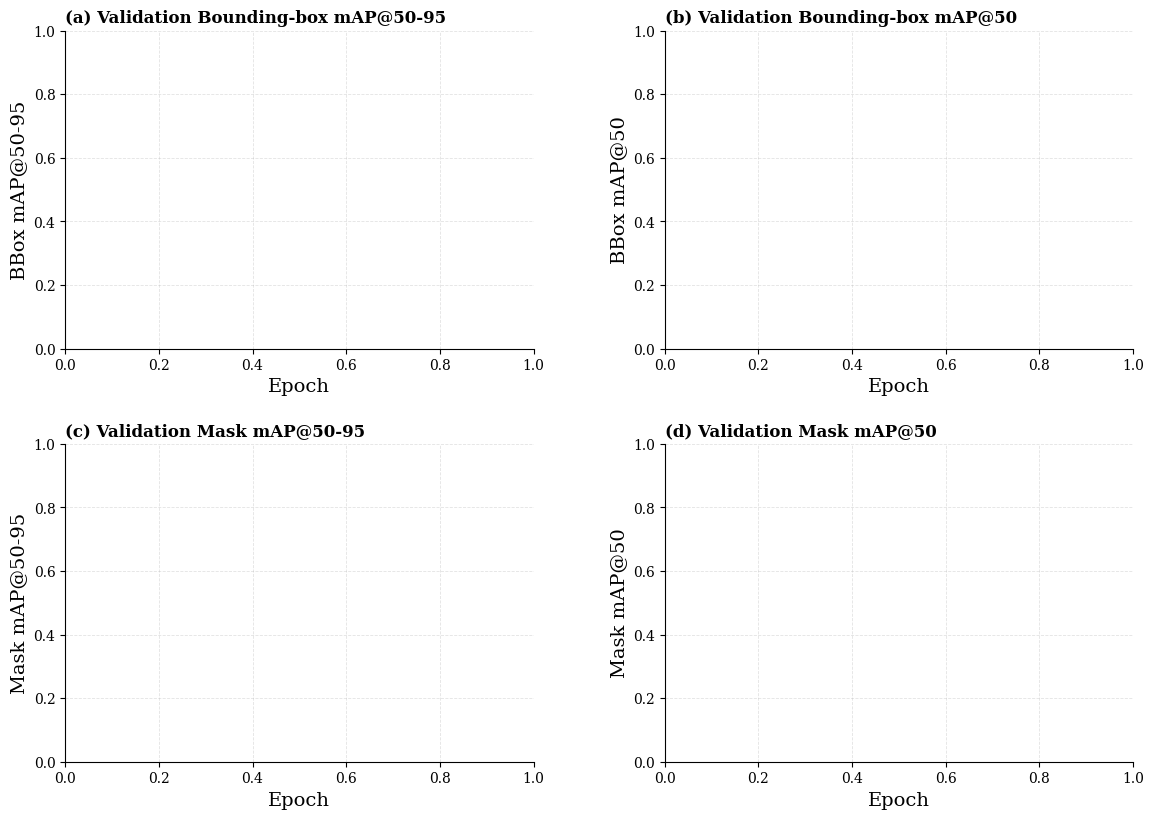

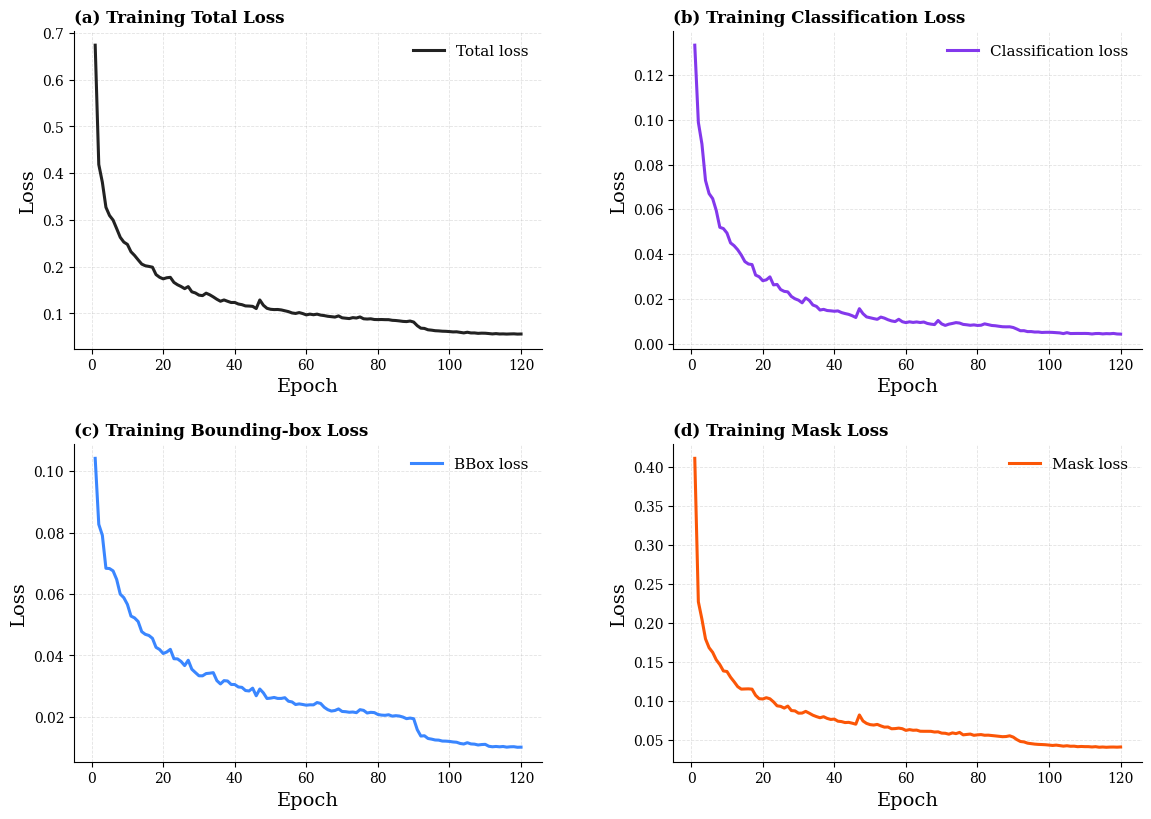


Gráficos guardados en: C:\workspace\mmdetection\work_dirs\mask_rcnn_fruits_r50_120e\_plots


In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
WORK_DIR = Path(r"C:\workspace\mmdetection\work_dirs\mask_rcnn_fruits_r50_120e")
OUT_DIR = WORK_DIR / "_plots"
OUT_DIR.mkdir(exist_ok=True, parents=True)

OUT_PNG = OUT_DIR / "maskrcnn_training_curves.png"
OUT_PDF = OUT_DIR / "maskrcnn_training_curves.pdf"

# =========================================================
# ESTILO
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.titlesize": 13,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# AUXILIARES
# =========================================================
def find_latest_log_json(work_dir: Path):
    candidates = list(work_dir.rglob("*.json"))
    # excluir archivos tipo notebook, config u otros si hiciera falta
    candidates = [p for p in candidates if p.name.endswith(".json")]
    if not candidates:
        raise FileNotFoundError(f"No se encontraron .json en {work_dir}")
    return max(candidates, key=lambda p: p.stat().st_mtime)

def load_mmengine_json_log(json_path: Path):
    rows = []
    with open(json_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                # algunos archivos pueden no ser JSON-lines puros
                continue

    if not rows:
        raise ValueError(f"No se pudieron leer entradas válidas desde {json_path}")

    df = pd.DataFrame(rows)
    return df

def pick_epoch_metric(df: pd.DataFrame, metric_name: str):
    if metric_name not in df.columns:
        return pd.DataFrame(columns=["epoch", metric_name])

    sub = df[["epoch", metric_name]].dropna()
    if sub.empty:
        return sub

    # dejar un valor por época
    sub = sub.groupby("epoch", as_index=False).last()
    return sub

def pick_train_metric(df: pd.DataFrame, metric_name: str):
    if metric_name not in df.columns:
        return pd.DataFrame(columns=["epoch", metric_name])

    sub = df[["epoch", metric_name]].dropna()
    if sub.empty:
        return sub

    # promedio por época para suavizar métricas por iteración
    sub = sub.groupby("epoch", as_index=False).mean()
    return sub

def plot_if_exists(ax, data, x, y, color, label, title, ylabel):
    if y in data.columns and not data.empty:
        ax.plot(data[x], data[y], color=color, linewidth=2.2, label=label)

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================================================
# CARGA DE LOG
# =========================================================
log_json = find_latest_log_json(WORK_DIR)
print(f"Usando log: {log_json}")

df = load_mmengine_json_log(log_json)

print("\nColumnas detectadas en el log:")
for c in df.columns:
    print(" -", c)

# =========================================================
# MÉTRICAS DE VALIDACIÓN
# =========================================================
bbox_map    = pick_epoch_metric(df, "coco/bbox_mAP")
segm_map    = pick_epoch_metric(df, "coco/segm_mAP")
bbox_map50  = pick_epoch_metric(df, "coco/bbox_mAP_50")
segm_map50  = pick_epoch_metric(df, "coco/segm_mAP_50")

# =========================================================
# MÉTRICAS DE TRAIN
# =========================================================
loss_total = pick_train_metric(df, "loss")
loss_bbox  = pick_train_metric(df, "loss_bbox")
loss_mask  = pick_train_metric(df, "loss_mask")
loss_cls   = pick_train_metric(df, "loss_cls")

# =========================================================
# FIGURA 1: VALIDACIÓN
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

plot_if_exists(
    axes[0, 0], bbox_map, "epoch", "coco/bbox_mAP",
    color="#3a86ff",
    label="BBox mAP",
    title="(a) Validation Bounding-box mAP@50-95",
    ylabel="BBox mAP@50-95"
)

plot_if_exists(
    axes[0, 1], bbox_map50, "epoch", "coco/bbox_mAP_50",
    color="#4361ee",
    label="BBox mAP@50",
    title="(b) Validation Bounding-box mAP@50",
    ylabel="BBox mAP@50"
)

plot_if_exists(
    axes[1, 0], segm_map, "epoch", "coco/segm_mAP",
    color="#fb5607",
    label="Segm mAP",
    title="(c) Validation Mask mAP@50-95",
    ylabel="Mask mAP@50-95"
)

plot_if_exists(
    axes[1, 1], segm_map50, "epoch", "coco/segm_mAP_50",
    color="#f4a261",
    label="Segm mAP@50",
    title="(d) Validation Mask mAP@50",
    ylabel="Mask mAP@50"
)

for ax in axes.ravel():
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(frameon=False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.94, bottom=0.08, wspace=0.28, hspace=0.30)
fig.savefig(OUT_DIR / "maskrcnn_val_metrics.png", dpi=600, bbox_inches="tight")
fig.savefig(OUT_DIR / "maskrcnn_val_metrics.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# FIGURA 2: TRAIN LOSSES
# =========================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8.5))

plot_if_exists(
    axes2[0, 0], loss_total, "epoch", "loss",
    color="#222222",
    label="Total loss",
    title="(a) Training Total Loss",
    ylabel="Loss"
)

plot_if_exists(
    axes2[0, 1], loss_cls, "epoch", "loss_cls",
    color="#8338ec",
    label="Classification loss",
    title="(b) Training Classification Loss",
    ylabel="Loss"
)

plot_if_exists(
    axes2[1, 0], loss_bbox, "epoch", "loss_bbox",
    color="#3a86ff",
    label="BBox loss",
    title="(c) Training Bounding-box Loss",
    ylabel="Loss"
)

plot_if_exists(
    axes2[1, 1], loss_mask, "epoch", "loss_mask",
    color="#fb5607",
    label="Mask loss",
    title="(d) Training Mask Loss",
    ylabel="Loss"
)

for ax in axes2.ravel():
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(frameon=False)

fig2.subplots_adjust(left=0.08, right=0.97, top=0.94, bottom=0.08, wspace=0.28, hspace=0.30)
fig2.savefig(OUT_DIR / "maskrcnn_train_losses.png", dpi=600, bbox_inches="tight")
fig2.savefig(OUT_DIR / "maskrcnn_train_losses.pdf", bbox_inches="tight")
plt.show()

print(f"\nGráficos guardados en: {OUT_DIR}")

In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
LOG_JSON = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\scalars.json")
OUT_DIR = LOG_JSON.parent / "_plots"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# =========================================================
# ESTILO
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# CARGA
# =========================================================
rows = []
with open(LOG_JSON, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

print("Columnas disponibles:")
for c in df.columns:
    print(" -", c)

# =========================================================
# FUNCIONES
# =========================================================
def metric_by_epoch(df, metric):
    if metric not in df.columns:
        return pd.DataFrame(columns=["epoch", metric])
    sub = df[["epoch", metric]].dropna()
    if sub.empty:
        return sub
    return sub.groupby("epoch", as_index=False).last()

def train_metric_by_epoch(df, metric):
    if metric not in df.columns:
        return pd.DataFrame(columns=["epoch", metric])
    sub = df[["epoch", metric]].dropna()
    if sub.empty:
        return sub
    return sub.groupby("epoch", as_index=False).mean()

def add_curve(ax, data, metric, color, label, title, ylabel):
    if not data.empty and metric in data.columns:
        ax.plot(data["epoch"], data[metric], linewidth=2.2, label=label)
        best_idx = data[metric].idxmax() if "mAP" in metric or metric == "acc" else data[metric].idxmin()
        best_epoch = data.loc[best_idx, "epoch"]
        best_val = data.loc[best_idx, metric]
        ax.scatter(best_epoch, best_val, s=40, zorder=3)
        ax.annotate(
            f"{best_val:.3f} (ep {int(best_epoch)})",
            (best_epoch, best_val),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9
        )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(frameon=False)

# =========================================================
# EXTRAER MÉTRICAS
# =========================================================
bbox_map    = metric_by_epoch(df, "coco/bbox_mAP")
bbox_map50  = metric_by_epoch(df, "coco/bbox_mAP_50")
segm_map    = metric_by_epoch(df, "coco/segm_mAP")
segm_map50  = metric_by_epoch(df, "coco/segm_mAP_50")

loss_total    = train_metric_by_epoch(df, "loss")
loss_rpn_cls  = train_metric_by_epoch(df, "loss_rpn_cls")
loss_rpn_bbox = train_metric_by_epoch(df, "loss_rpn_bbox")
loss_cls      = train_metric_by_epoch(df, "loss_cls")
loss_bbox     = train_metric_by_epoch(df, "loss_bbox")
loss_mask     = train_metric_by_epoch(df, "loss_mask")
acc_cls       = train_metric_by_epoch(df, "acc")

# =========================================================
# FIGURA 1: MÉTRICAS DE VALIDACIÓN
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

add_curve(
    axes[0, 0], bbox_map, "coco/bbox_mAP",
    color="C0", label="BBox mAP@50-95",
    title="(a) Validation Bounding-box mAP@50-95",
    ylabel="mAP"
)

add_curve(
    axes[0, 1], bbox_map50, "coco/bbox_mAP_50",
    color="C1", label="BBox mAP@50",
    title="(b) Validation Bounding-box mAP@50",
    ylabel="mAP@50"
)

add_curve(
    axes[1, 0], segm_map, "coco/segm_mAP",
    color="C2", label="Mask mAP@50-95",
    title="(c) Validation Mask mAP@50-95",
    ylabel="mAP"
)

add_curve(
    axes[1, 1], segm_map50, "coco/segm_mAP_50",
    color="C3", label="Mask mAP@50",
    title="(d) Validation Mask mAP@50",
    ylabel="mAP@50"
)

fig.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.08, wspace=0.28, hspace=0.32)
fig.savefig(OUT_DIR / "maskrcnn_val_metrics.png", dpi=600, bbox_inches="tight")
fig.savefig(OUT_DIR / "maskrcnn_val_metrics.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# FIGURA 2: PÉRDIDAS DE ENTRENAMIENTO
# =========================================================
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8.5))

add_curve(
    axes2[0, 0], loss_total, "loss",
    color="C0", label="Total loss",
    title="(a) Training Total Loss",
    ylabel="Loss"
)

add_curve(
    axes2[0, 1], loss_rpn_cls, "loss_rpn_cls",
    color="C1", label="RPN cls loss",
    title="(b) Training RPN Classification Loss",
    ylabel="Loss"
)

add_curve(
    axes2[0, 2], loss_rpn_bbox, "loss_rpn_bbox",
    color="C2", label="RPN bbox loss",
    title="(c) Training RPN Bounding-box Loss",
    ylabel="Loss"
)

add_curve(
    axes2[1, 0], loss_cls, "loss_cls",
    color="C3", label="ROI cls loss",
    title="(d) Training ROI Classification Loss",
    ylabel="Loss"
)

add_curve(
    axes2[1, 1], loss_bbox, "loss_bbox",
    color="C4", label="ROI bbox loss",
    title="(e) Training ROI Bounding-box Loss",
    ylabel="Loss"
)

add_curve(
    axes2[1, 2], loss_mask, "loss_mask",
    color="C5", label="Mask loss",
    title="(f) Training Mask Loss",
    ylabel="Loss"
)

fig2.subplots_adjust(left=0.06, right=0.98, top=0.95, bottom=0.08, wspace=0.28, hspace=0.32)
fig2.savefig(OUT_DIR / "maskrcnn_train_losses.png", dpi=600, bbox_inches="tight")
fig2.savefig(OUT_DIR / "maskrcnn_train_losses.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# FIGURA 3: ACCURACY DE CLASIFICACIÓN
# =========================================================
fig3, ax3 = plt.subplots(figsize=(7.5, 5.2))

add_curve(
    ax3, acc_cls, "acc",
    color="C6", label="Classification accuracy",
    title="Classification Accuracy During Training",
    ylabel="Accuracy"
)

fig3.subplots_adjust(left=0.12, right=0.97, top=0.92, bottom=0.12)
fig3.savefig(OUT_DIR / "maskrcnn_train_acc.png", dpi=600, bbox_inches="tight")
fig3.savefig(OUT_DIR / "maskrcnn_train_acc.pdf", bbox_inches="tight")
plt.show()

print(f"\nGráficos guardados en: {OUT_DIR}")

Columnas disponibles:
 - base_lr
 - lr
 - data_time
 - grad_norm
 - loss
 - loss_cls
 - loss_mask
 - loss_dice
 - d0.loss_cls
 - d0.loss_mask
 - d0.loss_dice
 - d1.loss_cls
 - d1.loss_mask
 - d1.loss_dice
 - d2.loss_cls
 - d2.loss_mask
 - d2.loss_dice
 - d3.loss_cls
 - d3.loss_mask
 - d3.loss_dice
 - d4.loss_cls
 - d4.loss_mask
 - d4.loss_dice
 - d5.loss_cls
 - d5.loss_mask
 - d5.loss_dice
 - d6.loss_cls
 - d6.loss_mask
 - d6.loss_dice
 - d7.loss_cls
 - d7.loss_mask
 - d7.loss_dice
 - d8.loss_cls
 - d8.loss_mask
 - d8.loss_dice
 - time
 - iter
 - memory
 - step
 - coco/bbox_mAP
 - coco/bbox_mAP_50
 - coco/bbox_mAP_75
 - coco/bbox_mAP_s
 - coco/bbox_mAP_m
 - coco/bbox_mAP_l
 - coco/segm_mAP
 - coco/segm_mAP_50
 - coco/segm_mAP_75
 - coco/segm_mAP_s
 - coco/segm_mAP_m
 - coco/segm_mAP_l


KeyError: "['epoch'] not in index"

In [37]:
def metric_with_fixed_epoch(df, metric, val_interval=5):
    sub = df.loc[df[metric].notna(), [metric]].copy()

    # 🔥 CRÍTICO: resetear índice
    sub = sub.reset_index(drop=True)

    # reconstruir epochs
    sub["epoch"] = (sub.index + 1) * val_interval

    return sub


bbox_map = metric_with_fixed_epoch(df, "coco/bbox_mAP", val_interval=5)
segm_map = metric_with_fixed_epoch(df, "coco/segm_mAP", val_interval=5)

print("BBox mAP:")
print(bbox_map)

print("\nSegm mAP:")
print(segm_map)

BBox mAP:
    coco/bbox_mAP  epoch
0           0.360      5
1           0.463     10
2           0.480     15
3           0.474     20
4           0.481     25
5           0.508     30
6           0.504     35
7           0.520     40
8           0.538     45
9           0.508     50
10          0.496     55
11          0.496     60
12          0.503     65
13          0.503     70
14          0.479     75

Segm mAP:
    coco/segm_mAP  epoch
0           0.383      5
1           0.474     10
2           0.486     15
3           0.490     20
4           0.491     25
5           0.518     30
6           0.506     35
7           0.519     40
8           0.536     45
9           0.524     50
10          0.493     55
11          0.499     60
12          0.508     65
13          0.496     70
14          0.468     75


   epoch  bbox_mAP_50_95  bbox_mAP_50  segm_mAP_50_95  segm_mAP_50
0      5           0.343        0.437           0.360        0.496
1     10           0.347        0.428           0.375        0.512
2     15           0.440        0.543           0.456        0.598
3     20           0.431        0.539           0.455        0.602
4     25           0.503        0.621           0.522        0.660
5     30           0.545        0.673           0.552        0.700
6     35           0.560        0.698           0.544        0.699
7     40           0.605        0.729           0.599        0.740
8     45           0.608        0.735           0.602        0.738
9     50           0.614        0.740           0.607        0.743


,epoch,bbox_mAP_50_95,bbox_mAP_50,segm_mAP_50_95,segm_mAP_50
0,5,0.343,0.437,0.360,0.496
1,10,0.347,0.428,0.375,0.512
2,15,0.440,0.543,0.456,0.598
3,20,0.431,0.539,0.455,0.602
4,25,0.503,0.621,0.522,0.660
5,30,0.545,0.673,0.552,0.700
6,35,0.560,0.698,0.544,0.699
7,40,0.605,0.729,0.599,0.740
8,45,0.608,0.735,0.602,0.738
9,50,0.614,0.740,0.607,0.743



CSV guardado en: work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\_plots\maskrcnn_val_metrics.csv


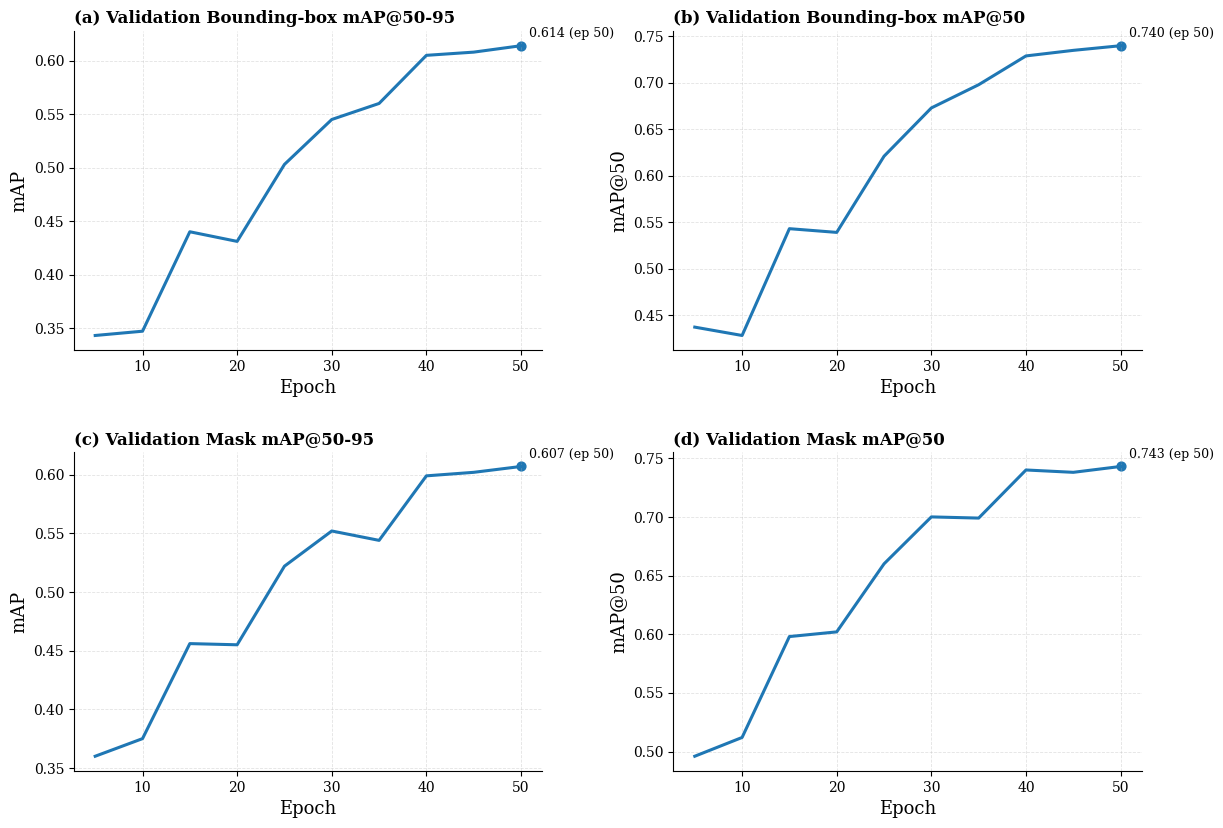


Figura guardada en:
- work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\_plots\maskrcnn_val_metrics.png
- work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\_plots\maskrcnn_val_metrics.pdf


In [6]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
LOG_JSON = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\scalars.json")
OUT_DIR = LOG_JSON.parent / "_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_INTERVAL = 5

# =========================================================
# CARGAR LOG
# =========================================================
rows = []
with open(LOG_JSON, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# =========================================================
# FUNCIÓN PARA RECONSTRUIR ÉPOCAS DE VALIDACIÓN
# =========================================================
def metric_with_fixed_epoch(df, metric, val_interval=5):
    sub = df.loc[df[metric].notna(), [metric]].copy()
    sub = sub.reset_index(drop=True)
    sub["epoch"] = (sub.index + 1) * val_interval
    return sub[["epoch", metric]]

# =========================================================
# EXTRAER MÉTRICAS DE VALIDACIÓN
# =========================================================
bbox_map = metric_with_fixed_epoch(df, "coco/bbox_mAP", VAL_INTERVAL)
bbox_map50 = metric_with_fixed_epoch(df, "coco/bbox_mAP_50", VAL_INTERVAL)
segm_map = metric_with_fixed_epoch(df, "coco/segm_mAP", VAL_INTERVAL)
segm_map50 = metric_with_fixed_epoch(df, "coco/segm_mAP_50", VAL_INTERVAL)

# =========================================================
# DATAFRAME FINAL: maskrcnn_val_metrics
# =========================================================
maskrcnn_val_metrics = pd.DataFrame({
    "epoch": bbox_map["epoch"],
    "bbox_mAP_50_95": bbox_map["coco/bbox_mAP"],
    "bbox_mAP_50": bbox_map50["coco/bbox_mAP_50"],
    "segm_mAP_50_95": segm_map["coco/segm_mAP"],
    "segm_mAP_50": segm_map50["coco/segm_mAP_50"],
})

print(maskrcnn_val_metrics)
display(maskrcnn_val_metrics)

# =========================================================
# GUARDAR CSV
# =========================================================
csv_path = OUT_DIR / "maskrcnn_val_metrics.csv"
maskrcnn_val_metrics.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\nCSV guardado en: {csv_path}")

# =========================================================
# GRAFICAR
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

# (a) bbox mAP@50-95
axes[0, 0].plot(maskrcnn_val_metrics["epoch"], maskrcnn_val_metrics["bbox_mAP_50_95"], linewidth=2.2)
best_idx = maskrcnn_val_metrics["bbox_mAP_50_95"].idxmax()
axes[0, 0].scatter(maskrcnn_val_metrics.loc[best_idx, "epoch"],
                   maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50_95"], s=40)
axes[0, 0].annotate(
    f'{maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50_95"]:.3f} (ep {int(maskrcnn_val_metrics.loc[best_idx, "epoch"])})',
    (maskrcnn_val_metrics.loc[best_idx, "epoch"], maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50_95"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9
)
axes[0, 0].set_title("(a) Validation Bounding-box mAP@50-95", loc="left", fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("mAP")
axes[0, 0].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

# (b) bbox mAP@50
axes[0, 1].plot(maskrcnn_val_metrics["epoch"], maskrcnn_val_metrics["bbox_mAP_50"], linewidth=2.2)
best_idx = maskrcnn_val_metrics["bbox_mAP_50"].idxmax()
axes[0, 1].scatter(maskrcnn_val_metrics.loc[best_idx, "epoch"],
                   maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50"], s=40)
axes[0, 1].annotate(
    f'{maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50"]:.3f} (ep {int(maskrcnn_val_metrics.loc[best_idx, "epoch"])})',
    (maskrcnn_val_metrics.loc[best_idx, "epoch"], maskrcnn_val_metrics.loc[best_idx, "bbox_mAP_50"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9
)
axes[0, 1].set_title("(b) Validation Bounding-box mAP@50", loc="left", fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("mAP@50")
axes[0, 1].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

# (c) segm mAP@50-95
axes[1, 0].plot(maskrcnn_val_metrics["epoch"], maskrcnn_val_metrics["segm_mAP_50_95"], linewidth=2.2)
best_idx = maskrcnn_val_metrics["segm_mAP_50_95"].idxmax()
axes[1, 0].scatter(maskrcnn_val_metrics.loc[best_idx, "epoch"],
                   maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50_95"], s=40)
axes[1, 0].annotate(
    f'{maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50_95"]:.3f} (ep {int(maskrcnn_val_metrics.loc[best_idx, "epoch"])})',
    (maskrcnn_val_metrics.loc[best_idx, "epoch"], maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50_95"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9
)
axes[1, 0].set_title("(c) Validation Mask mAP@50-95", loc="left", fontweight="bold")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("mAP")
axes[1, 0].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

# (d) segm mAP@50
axes[1, 1].plot(maskrcnn_val_metrics["epoch"], maskrcnn_val_metrics["segm_mAP_50"], linewidth=2.2)
best_idx = maskrcnn_val_metrics["segm_mAP_50"].idxmax()
axes[1, 1].scatter(maskrcnn_val_metrics.loc[best_idx, "epoch"],
                   maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50"], s=40)
axes[1, 1].annotate(
    f'{maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50"]:.3f} (ep {int(maskrcnn_val_metrics.loc[best_idx, "epoch"])})',
    (maskrcnn_val_metrics.loc[best_idx, "epoch"], maskrcnn_val_metrics.loc[best_idx, "segm_mAP_50"]),
    textcoords="offset points", xytext=(6, 6), fontsize=9
)
axes[1, 1].set_title("(d) Validation Mask mAP@50", loc="left", fontweight="bold")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("mAP@50")
axes[1, 1].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)

for ax in axes.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.08, wspace=0.28, hspace=0.32)

png_path = OUT_DIR / "maskrcnn_val_metrics.png"
pdf_path = OUT_DIR / "maskrcnn_val_metrics.pdf"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en:\n- {png_path}\n- {pdf_path}")

# mask2former

In [10]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
LOG_JSON = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\scalars.json")
OUT_DIR = LOG_JSON.parent / "_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# CARGAR LOG
# =========================================================
rows = []
with open(LOG_JSON, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

print("Columnas disponibles:")
for c in df.columns:
    print(" -", c)

# =========================================================
# FILTRAR SOLO MÉTRICAS DE ENTRENAMIENTO
# =========================================================
train_cols = [
    "epoch",
    "loss",
    "loss_cls",
    "loss_mask",
    "loss_dice",
    "lr",
    "grad_norm"
]

df_train = df[[c for c in train_cols if c in df.columns]].copy()
df_train = df_train.dropna(subset=["epoch"], how="any")

# convertir epoch a entero si viene flotante
df_train["epoch"] = df_train["epoch"].astype(int)

# agrupar por época y promediar
train_epoch = df_train.groupby("epoch", as_index=False).mean()

print("\nResumen por época:")
print(train_epoch.head())
print(train_epoch.tail())

# =========================================================
# GUARDAR CSV
# =========================================================
csv_path = OUT_DIR / "mask2former_train_metrics_by_epoch.csv"
train_epoch.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\nCSV guardado en: {csv_path}")

# =========================================================
# ESTILO
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# FUNCIÓN AUXILIAR
# =========================================================
def plot_metric(ax, df_plot, col, title, ylabel):
    ax.plot(df_plot["epoch"], df_plot[col], linewidth=2.2)

    # mejor punto: mínimo para pérdidas, máximo para lr/grad_norm no siempre tiene sentido,
    # pero aquí lo usamos solo en losses
    if "loss" in col:
        best_idx = df_plot[col].idxmin()
        best_val = df_plot.loc[best_idx, col]
        best_ep = df_plot.loc[best_idx, "epoch"]
        ax.scatter(best_ep, best_val, s=40, zorder=3)
        ax.annotate(
            f"{best_val:.3f} (ep {int(best_ep)})",
            (best_ep, best_val),
            textcoords="offset points",
            xytext=(6, 6),
            fontsize=9
        )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# =========================================================
# FIGURA 1: LOSSES DE ENTRENAMIENTO
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))

plot_metric(
    axes[0, 0], train_epoch, "loss",
    "(a) Training Total Loss",
    "Loss"
)

plot_metric(
    axes[0, 1], train_epoch, "loss_cls",
    "(b) Training Classification Loss",
    "Loss"
)

plot_metric(
    axes[1, 0], train_epoch, "loss_mask",
    "(c) Training Mask Loss",
    "Loss"
)

plot_metric(
    axes[1, 1], train_epoch, "loss_dice",
    "(d) Training Dice Loss",
    "Loss"
)

fig.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.08,
                    wspace=0.28, hspace=0.32)

png_path = OUT_DIR / "mask2former_train_losses_by_epoch.png"
pdf_path = OUT_DIR / "mask2former_train_losses_by_epoch.pdf"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en:\n- {png_path}\n- {pdf_path}")

# =========================================================
# FIGURA 2: LR Y GRAD_NORM
# =========================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.8))

axes2[0].plot(train_epoch["epoch"], train_epoch["lr"], linewidth=2.2)
axes2[0].set_title("(a) Learning Rate Schedule", loc="left", fontweight="bold")
axes2[0].set_xlabel("Epoch")
axes2[0].set_ylabel("Learning rate")
axes2[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
axes2[0].spines["top"].set_visible(False)
axes2[0].spines["right"].set_visible(False)

axes2[1].plot(train_epoch["epoch"], train_epoch["grad_norm"], linewidth=2.2)
axes2[1].set_title("(b) Gradient Norm", loc="left", fontweight="bold")
axes2[1].set_xlabel("Epoch")
axes2[1].set_ylabel("Grad norm")
axes2[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
axes2[1].spines["top"].set_visible(False)
axes2[1].spines["right"].set_visible(False)

fig2.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.12, wspace=0.28)

png_path2 = OUT_DIR / "mask2former_train_lr_gradnorm_by_epoch.png"
pdf_path2 = OUT_DIR / "mask2former_train_lr_gradnorm_by_epoch.pdf"

fig2.savefig(png_path2, dpi=600, bbox_inches="tight")
fig2.savefig(pdf_path2, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en:\n- {png_path2}\n- {pdf_path2}")

Columnas disponibles:
 - base_lr
 - lr
 - data_time
 - grad_norm
 - loss
 - loss_cls
 - loss_mask
 - loss_dice
 - d0.loss_cls
 - d0.loss_mask
 - d0.loss_dice
 - d1.loss_cls
 - d1.loss_mask
 - d1.loss_dice
 - d2.loss_cls
 - d2.loss_mask
 - d2.loss_dice
 - d3.loss_cls
 - d3.loss_mask
 - d3.loss_dice
 - d4.loss_cls
 - d4.loss_mask
 - d4.loss_dice
 - d5.loss_cls
 - d5.loss_mask
 - d5.loss_dice
 - d6.loss_cls
 - d6.loss_mask
 - d6.loss_dice
 - d7.loss_cls
 - d7.loss_mask
 - d7.loss_dice
 - d8.loss_cls
 - d8.loss_mask
 - d8.loss_dice
 - time
 - iter
 - memory
 - step
 - coco/bbox_mAP
 - coco/bbox_mAP_50
 - coco/bbox_mAP_75
 - coco/bbox_mAP_s
 - coco/bbox_mAP_m
 - coco/bbox_mAP_l
 - coco/segm_mAP
 - coco/segm_mAP_50
 - coco/segm_mAP_75
 - coco/segm_mAP_s
 - coco/segm_mAP_m
 - coco/segm_mAP_l


KeyError: ['epoch']

In [ ]:
python tools/test.py configs/mask2former/mask2former_fruits_r50.py work_dirs/mask2former_fruits_r50_50e_v1/best_coco_segm_mAP_iter_61200.pth --out work_dirs/mask2former_fruits_r50_50e_v1/preds.pkl

In [8]:
from mmengine.fileio import load

PKL_PATH = r"work_dirs/mask2former_fruits_r50_50e_v1/preds.pkl"
results = load(PKL_PATH)

print(type(results))
print(type(results[0]))
print(results[0].keys())

<class 'list'>
<class 'dict'>
dict_keys(['scale_factor', 'batch_input_shape', 'img_path', 'pad_shape', 'ori_shape', 'img_id', 'img_shape', 'pred_instances'])


In [10]:
from mmengine.fileio import load
import json
import numpy as np
from pycocotools import mask as mask_utils

# =========================
# PATHS
# =========================
PKL_PATH = r"work_dirs\mask2former_fruits_r50_50e_v1\preds.pkl"

OUT_BBOX = r"work_dirs\mask2former_fruits_r50_50e_v1\preds_bbox.json"
OUT_SEGM = r"work_dirs\mask2former_fruits_r50_50e_v1\preds_segm.json"

# =========================
# CARGAR RESULTADOS
# =========================
results = load(PKL_PATH)

bbox_json = []
segm_json = []

for res in results:
    if res is None:
        continue

    img_id = int(res["img_id"])
    pred_instances = res["pred_instances"]

    # pred_instances puede venir como dict de arrays/tensores
    bboxes = pred_instances["bboxes"]
    scores = pred_instances["scores"]
    labels = pred_instances["labels"]
    masks = pred_instances["masks"] if "masks" in pred_instances else None

    # convertir a numpy si hace falta
    if hasattr(bboxes, "cpu"):
        bboxes = bboxes.cpu().numpy()
    else:
        bboxes = np.array(bboxes)

    if hasattr(scores, "cpu"):
        scores = scores.cpu().numpy()
    else:
        scores = np.array(scores)

    if hasattr(labels, "cpu"):
        labels = labels.cpu().numpy()
    else:
        labels = np.array(labels)

    if masks is not None:
        if hasattr(masks, "cpu"):
            masks = masks.cpu().numpy()
        else:
            masks = np.array(masks)

    for i in range(len(bboxes)):
        x1, y1, x2, y2 = bboxes[i]
        w = x2 - x1
        h = y2 - y1

        bbox_json.append({
            "image_id": img_id,
            "category_id": int(labels[i]),
            "bbox": [float(x1), float(y1), float(w), float(h)],
            "score": float(scores[i])
        })

        if masks is not None:
            mask = masks[i]

            # Si counts viene en bytes → convertir a string
            if isinstance(mask["counts"], bytes):
                mask["counts"] = mask["counts"].decode("utf-8")

            rle = mask

            segm_json.append({
                "image_id": img_id,
                "category_id": int(labels[i]),
                "segmentation": rle,
                "score": float(scores[i])
            })

# =========================
# GUARDAR
# =========================
with open(OUT_BBOX, "w", encoding="utf-8") as f:
    json.dump(bbox_json, f)

with open(OUT_SEGM, "w", encoding="utf-8") as f:
    json.dump(segm_json, f)

print("Listo:")
print(" -", OUT_BBOX)
print(" -", OUT_SEGM)
print(f"Total bbox preds: {len(bbox_json)}")
print(f"Total segm preds: {len(segm_json)}")

Listo:
 - work_dirs\mask2former_fruits_r50_50e_v1\preds_bbox.json
 - work_dirs\mask2former_fruits_r50_50e_v1\preds_segm.json
Total bbox preds: 49100
Total segm preds: 49100


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.51s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.78s).
Accumulating evaluation results...
DONE (t=0.35s).


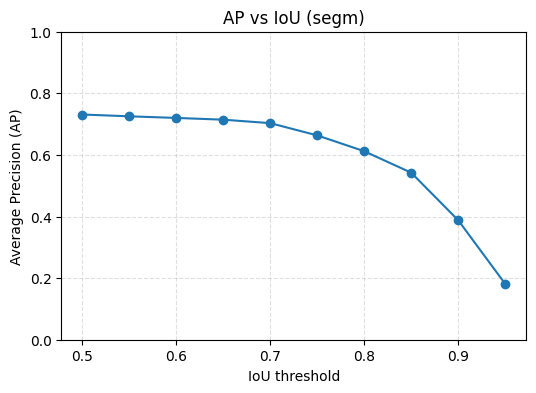

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

GT_JSON = r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val.json"
PRED_JSON = r"work_dirs\mask2former_fruits_r50_50e_v1\preds_segm.json"   # o preds_bbox.json
EVAL_TYPE = "segm"  # "bbox" o "segm"

gt = COCO(GT_JSON)
pred = gt.loadRes(PRED_JSON)

e = COCOeval(gt, pred, EVAL_TYPE)
e.evaluate()
e.accumulate()

# precisions: [TxRxKxAxM] → T=IoU thresholds, R=recall points
prec = e.eval['precision']  # shape: (T, R, K, A, M)

# Promediamos sobre recall, clases, áreas y maxDets
# y dejamos solo el eje IoU (T)
prec_mean_over_r = np.nanmean(prec, axis=1)   # (T, K, A, M)
prec_mean = np.nanmean(prec_mean_over_r, axis=(1,2,3))  # (T,)

ious = e.params.iouThrs  # array de IoU thresholds

plt.figure(figsize=(6,4))
plt.plot(ious, prec_mean, marker='o')
plt.xlabel("IoU threshold")
plt.ylabel("Average Precision (AP)")
plt.title(f"AP vs IoU ({EVAL_TYPE})")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0,1)
plt.show()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.25s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.48s).
Accumulating evaluation results...
DONE (t=0.35s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.614
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.740
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.677
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.671
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.627
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.583
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.773
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.855
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

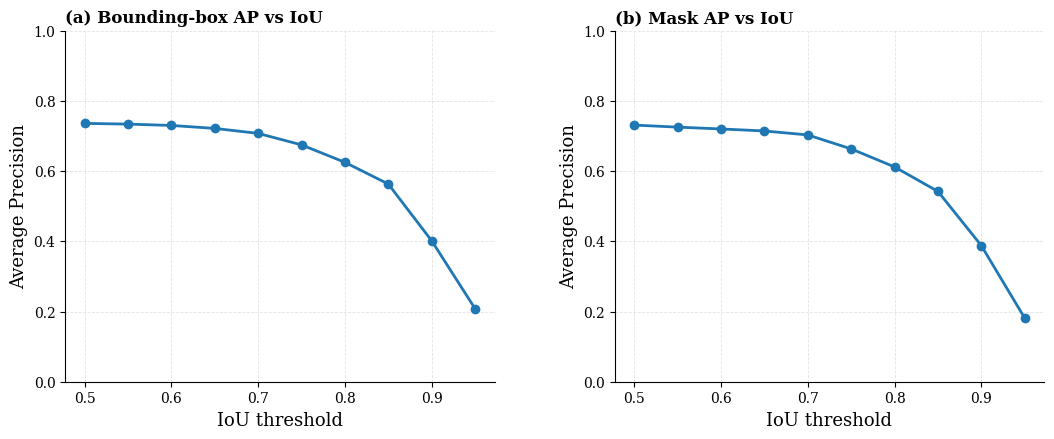


Curvas IoU guardadas en:
- C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v1\_metrics\mask2former_ap_vs_iou.png
- C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v1\_metrics\mask2former_ap_vs_iou.pdf


In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as mask_utils

# =========================================================
# CONFIG
# =========================================================
GT_JSON = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val.json")
PRED_BBOX_JSON = Path(r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v1\preds_bbox.json")
PRED_SEGM_JSON = Path(r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v1\preds_segm.json")

OUT_DIR = PRED_BBOX_JSON.parent / "_metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IOU_MATCH_THR = 0.50
SCORE_THR = 0.25

# =========================================================
# AUXILIARES
# =========================================================
def f1_score(p, r):
    return 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

def bbox_xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def bbox_iou(box1, box2):
    x1_min, y1_min, x1_max, y1_max = bbox_xywh_to_xyxy(box1)
    x2_min, y2_min, x2_max, y2_max = bbox_xywh_to_xyxy(box2)

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_w = max(0.0, inter_xmax - inter_xmin)
    inter_h = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = max(0.0, x1_max - x1_min) * max(0.0, y1_max - y1_min)
    area2 = max(0.0, x2_max - x2_min) * max(0.0, y2_max - y2_min)

    union = area1 + area2 - inter_area
    return 0.0 if union <= 0 else inter_area / union

def coco_eval_full(gt_coco, pred_json, eval_type="bbox"):
    pred_coco = gt_coco.loadRes(str(pred_json))
    coco_eval = COCOeval(gt_coco, pred_coco, eval_type)
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    return coco_eval

def build_gt_index(gt_coco):
    gt_by_image_cat = defaultdict(list)
    for img_id in gt_coco.getImgIds():
        ann_ids = gt_coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = gt_coco.loadAnns(ann_ids)
        for ann in anns:
            gt_by_image_cat[(img_id, ann["category_id"])].append(ann)
    return gt_by_image_cat

def build_pred_index(preds, score_thr=0.25):
    pred_by_image_cat = defaultdict(list)
    for pred in preds:
        if pred.get("score", 0.0) >= score_thr:
            pred_by_image_cat[(pred["image_id"], pred["category_id"])].append(pred)

    for key in pred_by_image_cat:
        pred_by_image_cat[key] = sorted(
            pred_by_image_cat[key],
            key=lambda x: x["score"],
            reverse=True
        )
    return pred_by_image_cat

def compute_prf_bbox(gt_coco, pred_json, iou_thr=0.5, score_thr=0.25):
    with open(pred_json, "r", encoding="utf-8") as f:
        preds = json.load(f)

    gt_by_image_cat = build_gt_index(gt_coco)
    pred_by_image_cat = build_pred_index(preds, score_thr)
    all_keys = set(gt_by_image_cat.keys()) | set(pred_by_image_cat.keys())

    TP, FP, FN = 0, 0, 0

    for key in all_keys:
        gts = gt_by_image_cat.get(key, [])
        prs = pred_by_image_cat.get(key, [])
        matched_gt = set()

        for pred in prs:
            best_iou = -1.0
            best_gt_idx = -1
            for i, gt in enumerate(gts):
                if i in matched_gt:
                    continue
                iou = bbox_iou(pred["bbox"], gt["bbox"])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i

            if best_iou >= iou_thr and best_gt_idx >= 0:
                TP += 1
                matched_gt.add(best_gt_idx)
            else:
                FP += 1

        FN += len(gts) - len(matched_gt)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return precision, recall, f1_score(precision, recall)

def compute_prf_mask(gt_coco, pred_json, iou_thr=0.5, score_thr=0.25):
    with open(pred_json, "r", encoding="utf-8") as f:
        preds = json.load(f)

    gt_by_image_cat = build_gt_index(gt_coco)
    pred_by_image_cat = build_pred_index(preds, score_thr)
    all_keys = set(gt_by_image_cat.keys()) | set(pred_by_image_cat.keys())

    TP, FP, FN = 0, 0, 0

    for key in all_keys:
        gts = gt_by_image_cat.get(key, [])
        prs = pred_by_image_cat.get(key, [])
        matched_gt = set()

        gt_rles = []
        for gt in gts:
            gt_ann = gt.copy()
            rle = gt_coco.annToRLE(gt_ann)
            gt_rles.append(rle)

        for pred in prs:
            pred_seg = pred.get("segmentation", None)
            if pred_seg is None:
                FP += 1
                continue

            best_iou = -1.0
            best_gt_idx = -1

            for i, gt_rle in enumerate(gt_rles):
                if i in matched_gt:
                    continue
                iou = mask_utils.iou([pred_seg], [gt_rle], [0])[0][0]
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i

            if best_iou >= iou_thr and best_gt_idx >= 0:
                TP += 1
                matched_gt.add(best_gt_idx)
            else:
                FP += 1

        FN += len(gts) - len(matched_gt)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return precision, recall, f1_score(precision, recall)

def ap_vs_iou(coco_eval):
    prec = coco_eval.eval["precision"]  # (T, R, K, A, M)
    ious = coco_eval.params.iouThrs
    prec_mean = np.nanmean(prec, axis=1)      # over recall
    prec_mean = np.nanmean(prec_mean, axis=(1, 2, 3))  # over class/area/maxdets
    return ious, prec_mean

# =========================================================
# CARGAR GT
# =========================================================
gt_coco = COCO(str(GT_JSON))

# =========================================================
# EVALUACIÓN COCO
# =========================================================
bbox_eval = coco_eval_full(gt_coco, PRED_BBOX_JSON, "bbox")
segm_eval = coco_eval_full(gt_coco, PRED_SEGM_JSON, "segm")

map_b = float(bbox_eval.stats[0])   # AP@[.50:.95]
map_m = float(segm_eval.stats[0])   # AP@[.50:.95]

# OJO: stats[6] = AR@[.50:.95] | area=all | maxDets=1
#      stats[7] = AR@[.50:.95] | area=all | maxDets=10
#      stats[8] = AR@[.50:.95] | area=all | maxDets=100
# Para tu resumen final, usamos maxDets=100
ar_b = float(bbox_eval.stats[8])
ar_m = float(segm_eval.stats[8])

# =========================================================
# PREC / REC / F1 (MATCHING A IoU=0.50)
# =========================================================
prec_b, rec_b, f1_b = compute_prf_bbox(
    gt_coco, PRED_BBOX_JSON, iou_thr=IOU_MATCH_THR, score_thr=SCORE_THR
)

prec_m, rec_m, f1_m = compute_prf_mask(
    gt_coco, PRED_SEGM_JSON, iou_thr=IOU_MATCH_THR, score_thr=SCORE_THR
)

# =========================================================
# TABLA FINAL
# =========================================================
df_final = pd.DataFrame([{
    "Model Var.": "Mask2Former",
    "mAP50-95 (B)": round(map_b, 3),
    "mAP50-95 (M)": round(map_m, 3),
    "Prec (B)": round(prec_b, 3),
    "Rec (B)": round(rec_b, 3),
    "F1 (B)": round(f1_b, 3),
    "Prec (M)": round(prec_m, 3),
    "Rec (M)": round(rec_m, 3),
    "F1 (M)": round(f1_m, 3),
}])

print("\nTabla final:")
print(df_final)

csv_path = OUT_DIR / "mask2former_final_metrics.csv"
df_final.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"\nCSV guardado en: {csv_path}")

# =========================================================
# CURVAS AP VS IoU
# =========================================================
ious_b, ap_curve_b = ap_vs_iou(bbox_eval)
ious_m, ap_curve_m = ap_vs_iou(segm_eval)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(ious_b, ap_curve_b, marker="o", linewidth=2.0)
axes[0].set_title("(a) Bounding-box AP vs IoU", loc="left", fontweight="bold")
axes[0].set_xlabel("IoU threshold")
axes[0].set_ylabel("Average Precision")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(ious_m, ap_curve_m, marker="o", linewidth=2.0)
axes[1].set_title("(b) Mask AP vs IoU", loc="left", fontweight="bold")
axes[1].set_xlabel("IoU threshold")
axes[1].set_ylabel("Average Precision")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.14, wspace=0.28)

png_iou = OUT_DIR / "mask2former_ap_vs_iou.png"
pdf_iou = OUT_DIR / "mask2former_ap_vs_iou.pdf"
fig.savefig(png_iou, dpi=600, bbox_inches="tight")
fig.savefig(pdf_iou, bbox_inches="tight")
plt.show()

print(f"\nCurvas IoU guardadas en:\n- {png_iou}\n- {pdf_iou}")

     Model Var.  mAP50-95 (B)  mAP50-95 (M)  mAP50 (B)  mAP50 (M)
0      V11n_640      0.073846      0.069414   0.102640   0.102857
1      V11s_640      0.084836      0.080788   0.115552   0.115552
2      V11m_640      0.088557      0.084520   0.113916   0.113916
3      V11l_640      0.072084      0.068245   0.094497   0.094682
4      V11x_640      0.072227      0.069300   0.095843   0.095843
5      V26n_640      0.077960      0.074388   0.104427   0.104836
6      V26s_640      0.075664      0.073002   0.104062   0.103693
7      V26m_640      0.072972      0.070295   0.102841   0.103060
8      V26l_640      0.071351      0.068637   0.097469   0.097469
9      V26x_640      0.078558      0.075815   0.107108   0.108025
10  Mask2Former      0.614000      0.607000   0.740000   0.743000


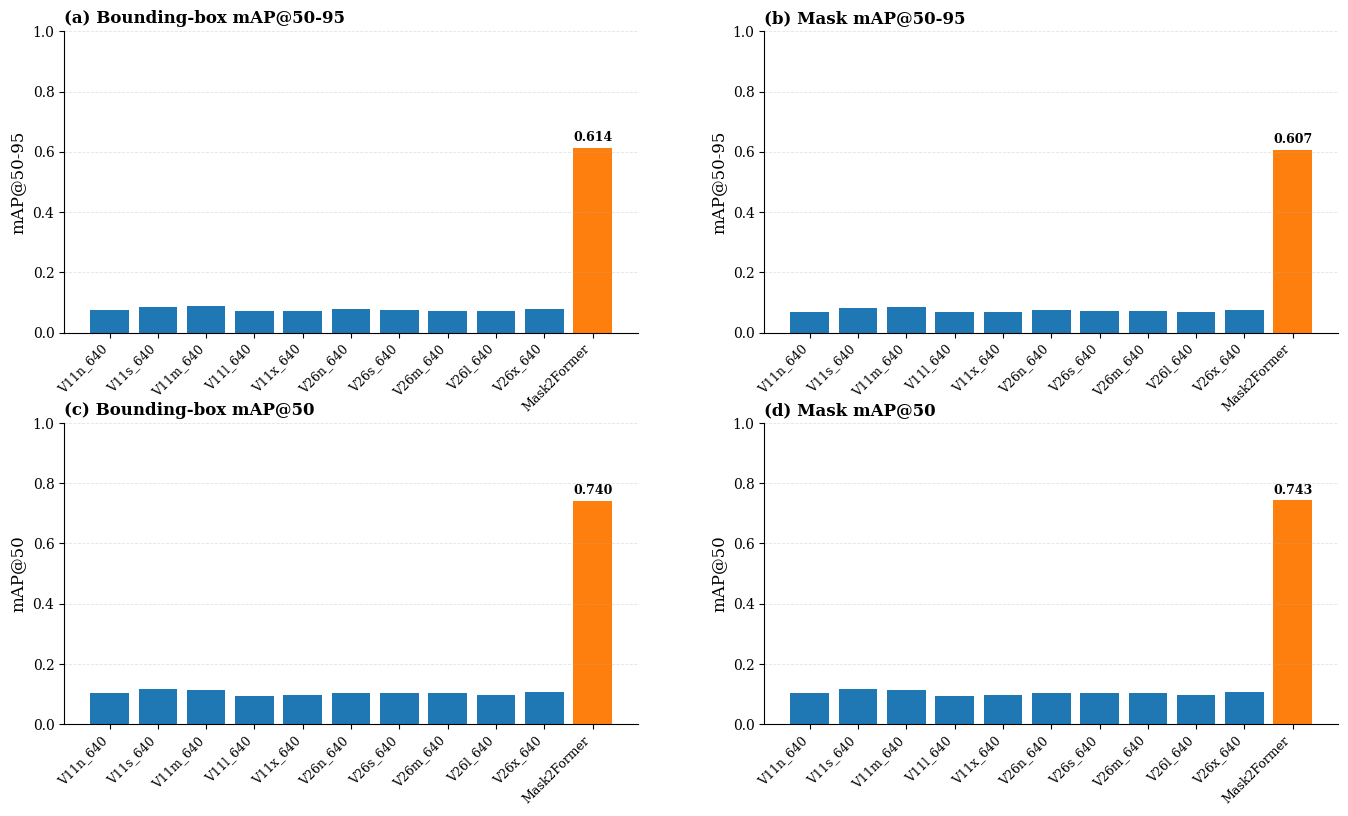


Archivos guardados:
 - C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_iou_curves\_comparison_plots\combined_model_metrics.csv
 - C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_iou_curves\_comparison_plots\yolo_vs_mask2former_comparison.png
 - C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_iou_curves\_comparison_plots\yolo_vs_mask2former_comparison.pdf


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# PATHS
# =========================================================
YOLO_CSV = Path(r"C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_iou_curves\yolo_runs_iou_summary.csv")
MASK2FORMER_CSV = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\_metrics\mask2former_final_metrics.csv")

OUT_DIR = YOLO_CSV.parent / "_comparison_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# CARGAR CSVs
# =========================================================
df_yolo = pd.read_csv(YOLO_CSV)
df_m2f = pd.read_csv(MASK2FORMER_CSV)

# =========================================================
# NORMALIZAR NOMBRES DE COLUMNAS
# =========================================================
# YOLO summary esperado:
# run, bbox_mAP_50_95, bbox_mAP_50, segm_mAP_50_95, segm_mAP_50

df_yolo = df_yolo.rename(columns={
    "run": "Model Var.",
    "bbox_mAP_50_95": "mAP50-95 (B)",
    "segm_mAP_50_95": "mAP50-95 (M)",
    "bbox_mAP_50": "mAP50 (B)",
    "segm_mAP_50": "mAP50 (M)",
})

# Mask2Former CSV esperado:
# Model Var., mAP50-95 (B), mAP50-95 (M), Prec (B), Rec (B), ...
# Si no tiene mAP50(B/M), los reconstruimos desde tus valores conocidos.
if "mAP50 (B)" not in df_m2f.columns:
    df_m2f["mAP50 (B)"] = 0.740

if "mAP50 (M)" not in df_m2f.columns:
    df_m2f["mAP50 (M)"] = 0.743

# =========================================================
# SELECCIONAR COLUMNAS COMUNES
# =========================================================
keep_cols = ["Model Var.", "mAP50-95 (B)", "mAP50-95 (M)", "mAP50 (B)", "mAP50 (M)"]

df_yolo = df_yolo[keep_cols].copy()
df_m2f = df_m2f[keep_cols].copy()

# =========================================================
# COMBINAR
# =========================================================
df_all = pd.concat([df_yolo, df_m2f], ignore_index=True)

# =========================================================
# ORDENAR MODELOS
# =========================================================
desired_order = [
    "V11n_640", "V11s_640", "V11m_640", "V11l_640", "V11x_640",
    "V26n_640", "V26s_640", "V26m_640", "V26l_640", "V26x_640",
    "Mask2Former"
]

df_all["Model Var."] = pd.Categorical(df_all["Model Var."], categories=desired_order, ordered=True)
df_all = df_all.sort_values("Model Var.").reset_index(drop=True)

print(df_all)

# =========================================================
# ESTILO
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# FUNCIÓN AUXILIAR
# =========================================================
def plot_bar(ax, df, col, title, ylabel):
    x = range(len(df))
    y = df[col].values

    bars = ax.bar(x, y)

    # resaltar Mask2Former
    for i, name in enumerate(df["Model Var."]):
        if name == "Mask2Former":
            bars[i].set_linewidth(1.5)

    best_idx = df[col].idxmax()
    ax.bar(best_idx, df.loc[best_idx, col])

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["Model Var."], rotation=45, ha="right")
    ax.set_ylim(0, 1.0)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.annotate(
        f'{df.loc[best_idx, col]:.3f}',
        (best_idx, df.loc[best_idx, col]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# =========================================================
# FIGURA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_bar(
    axes[0, 0], df_all,
    "mAP50-95 (B)",
    "(a) Bounding-box mAP@50-95",
    "mAP@50-95"
)

plot_bar(
    axes[0, 1], df_all,
    "mAP50-95 (M)",
    "(b) Mask mAP@50-95",
    "mAP@50-95"
)

plot_bar(
    axes[1, 0], df_all,
    "mAP50 (B)",
    "(c) Bounding-box mAP@50",
    "mAP@50"
)

plot_bar(
    axes[1, 1], df_all,
    "mAP50 (M)",
    "(d) Mask mAP@50",
    "mAP@50"
)

fig.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.18,
                    wspace=0.22, hspace=0.30)

# =========================================================
# GUARDAR
# =========================================================
png_path = OUT_DIR / "yolo_vs_mask2former_comparison.png"
pdf_path = OUT_DIR / "yolo_vs_mask2former_comparison.pdf"
csv_path = OUT_DIR / "combined_model_metrics.csv"

df_all.to_csv(csv_path, index=False, encoding="utf-8-sig")
fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

plt.show()

print("\nArchivos guardados:")
print(" -", csv_path)
print(" -", png_path)
print(" -", pdf_path)

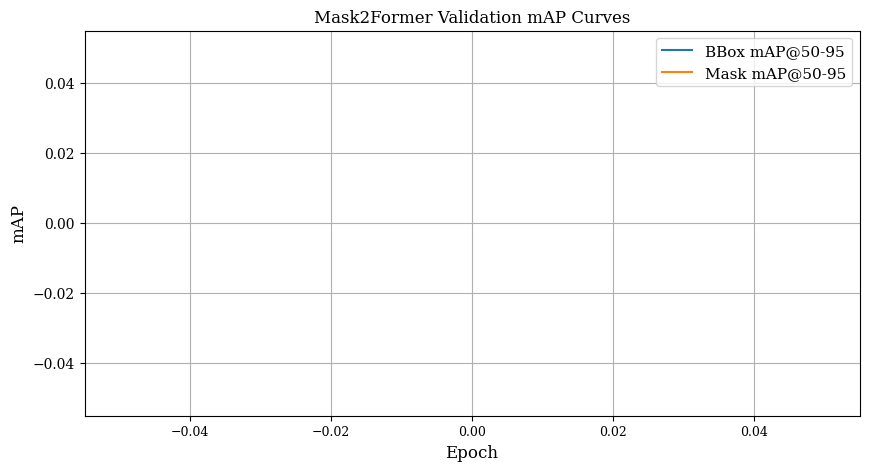

In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\scalars.json")

# =========================
# CARGAR LOG
# =========================
data = []
with open(LOG_PATH, "r") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

# =========================
# FILTRAR SOLO VALIDACIÓN
# =========================
df_val = df[df["coco/bbox_mAP"].notna()].copy()

# =========================
# CREAR EJE "epoch"
# =========================
# Aproximación (ajusta si quieres precisión exacta)
iters_per_epoch = 612   # <- en tu caso
df_val["epoch"] = df_val["iter"] / iters_per_epoch

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,5))

plt.plot(df_val["epoch"], df_val["coco/bbox_mAP"], label="BBox mAP@50-95")
plt.plot(df_val["epoch"], df_val["coco/segm_mAP"], label="Mask mAP@50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Mask2Former Validation mAP Curves")
plt.legend()
plt.grid(True)

plt.show()

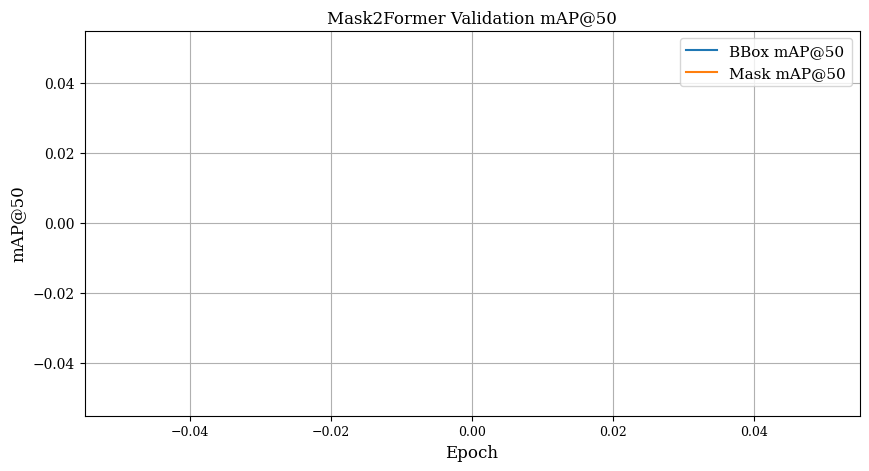

In [18]:
plt.figure(figsize=(10,5))

plt.plot(df_val["epoch"], df_val["coco/bbox_mAP_50"], label="BBox mAP@50")
plt.plot(df_val["epoch"], df_val["coco/segm_mAP_50"], label="Mask mAP@50")

plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("Mask2Former Validation mAP@50")
plt.legend()
plt.grid(True)

plt.show()

Filas de validación: 10
Index(['coco/bbox_mAP', 'coco/bbox_mAP_50', 'coco/bbox_mAP_75',
       'coco/bbox_mAP_s', 'coco/bbox_mAP_m', 'coco/bbox_mAP_l',
       'coco/segm_mAP', 'coco/segm_mAP_50', 'coco/segm_mAP_75',
       'coco/segm_mAP_s', 'coco/segm_mAP_m', 'coco/segm_mAP_l', 'data_time',
       'time', 'step'],
      dtype='object')
   epoch  coco/bbox_mAP  coco/segm_mAP
0      5          0.343          0.360
1     10          0.347          0.375
2     15          0.440          0.456
3     20          0.431          0.455
4     25          0.503          0.522
5     30          0.545          0.552
6     35          0.560          0.544
7     40          0.605          0.599
8     45          0.608          0.602
9     50          0.614          0.607


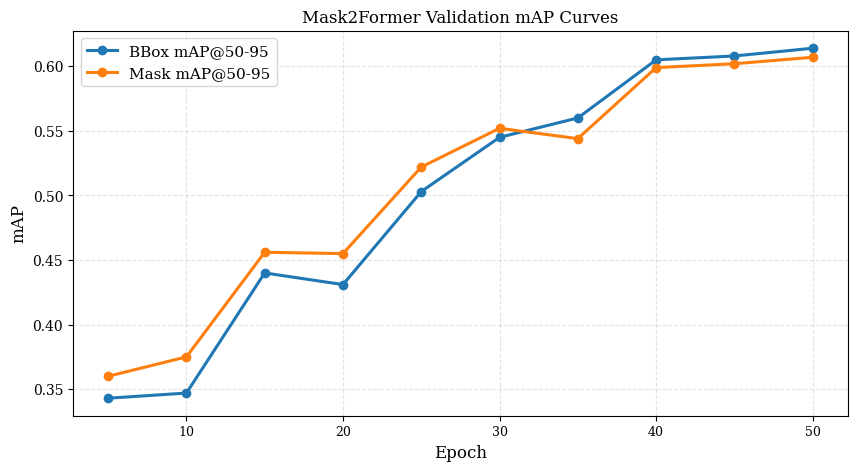

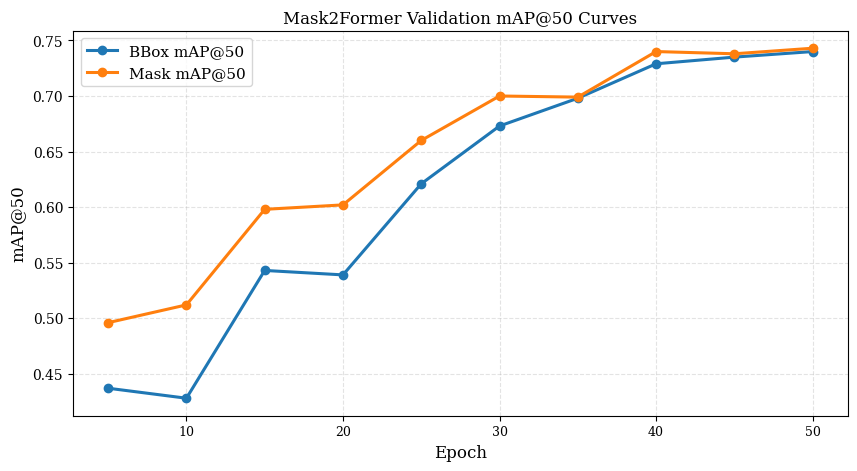

In [22]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\20260420_183145\vis_data\scalars.json")

# =========================
# CARGAR SOLO VALIDACIÓN
# =========================
records = []
with open(LOG_PATH, "r", encoding="utf-8") as f:
    for line in f:
        d = json.loads(line)
        if "coco/bbox_mAP" in d:
            records.append(d)

df_val = pd.DataFrame(records)

print("Filas de validación:", len(df_val))
print(df_val.columns)

# =========================
# ASEGURAR NUMÉRICOS
# =========================
for col in [
    "coco/bbox_mAP",
    "coco/segm_mAP",
    "coco/bbox_mAP_50",
    "coco/segm_mAP_50",
]:
    df_val[col] = pd.to_numeric(df_val[col], errors="coerce")

df_val = df_val.dropna(subset=["coco/bbox_mAP"]).reset_index(drop=True)

# =========================
# RECONSTRUIR ÉPOCAS
# =========================
VAL_INTERVAL = 5
df_val["epoch"] = (df_val.index + 1) * VAL_INTERVAL

print(df_val[["epoch", "coco/bbox_mAP", "coco/segm_mAP"]])

# =========================
# PLOT 1: mAP50-95
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_val["epoch"], df_val["coco/bbox_mAP"], marker="o", linewidth=2.2, label="BBox mAP@50-95")
plt.plot(df_val["epoch"], df_val["coco/segm_mAP"], marker="o", linewidth=2.2, label="Mask mAP@50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Mask2Former Validation mAP Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.35)
plt.show()

# =========================
# PLOT 2: mAP50
# =========================
plt.figure(figsize=(10, 5))
plt.plot(df_val["epoch"], df_val["coco/bbox_mAP_50"], marker="o", linewidth=2.2, label="BBox mAP@50")
plt.plot(df_val["epoch"], df_val["coco/segm_mAP_50"], marker="o", linewidth=2.2, label="Mask mAP@50")

plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("Mask2Former Validation mAP@50 Curves")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.35)
plt.show()

## validacion por clase

creacion de dataset val

In [8]:
# =========================================================
# DATAFRAME FINAL
# =========================================================
df = pd.DataFrame(results)
df = df.sort_values(["model", "visibility", "epoch"])

# =========================================================
# GRAFICO mAP
# =========================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for (model, vis), sub in df.groupby(["model", "visibility"]):
    sub = sub.sort_values("epoch")

    plt.plot(
        sub["epoch"],
        sub["mask_mAP50_95"],
        label=f"{model} - {vis}",
        linewidth=2 if model == "Mask2Former" else 1.5
    )

plt.xlabel("Epoch")
plt.ylabel("Mask mAP@50-95")
plt.title("Segmentation Performance vs Epoch (by Visibility)")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'results' is not defined

In [30]:
import subprocess
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================

CONFIG_BASE = Path(r"configs/mask2former/mask2former_fruits_r50.py")
CHECKPOINT = Path(r"work_dirs\mask2former_fruits_r50_50e_v1\best_coco_segm_mAP_iter_61200.pth")
print(CHECKPOINT.exists(), CHECKPOINT)
COCO_ROOT = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset")
ann = COCO_ROOT / "annotations" / "instances_val_25.json"

with open(ann, "r", encoding="utf-8") as f:
    data = json.load(f)

file_name = data["images"][0]["file_name"]
img_path = COCO_ROOT / file_name

print("file_name en JSON:", file_name)
print("ruta completa:", img_path)
print("existe imagen:", img_path.exists())

OUT_DIR = Path("mask2former_visibility_eval")
OUT_DIR.mkdir(exist_ok=True)

VISIBILITY_LEVELS = ["25%", "50%", "75%", "100%"]

def safe_level(level):
    return level.replace("%", "")

# =========================================================
# LOOP
# =========================================================

for level in VISIBILITY_LEVELS:
    level_safe = safe_level(level)

    print(f"\nEvaluando Mask2Former en visibilidad {level}")

    temp_config = OUT_DIR / f"mask2former_val_{level_safe}.py"

    cfg_text = CONFIG_BASE.read_text(encoding="utf-8")

    cfg_text += f"""

# =========================================================
# OVERRIDE VALIDATION DATASET - VISIBILITY {level}
# =========================================================

val_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type='CocoDataset',
        metainfo=dict(classes=classes),
        data_root=r'{COCO_ROOT.as_posix()}',
        ann_file='annotations/instances_val_{level_safe}.json',
        data_prefix=dict(img=''),
        test_mode=True,
    )
)

test_dataloader = val_dataloader

val_evaluator = dict(
    type='CocoMetric',
    ann_file=r'{(COCO_ROOT / "annotations" / f"instances_val_{level_safe}.json").as_posix()}',
    metric=['bbox', 'segm'],
    format_only=False
)

test_evaluator = val_evaluator
"""

    temp_config.write_text(cfg_text, encoding="utf-8")

    cmd = [
        "python",
        "tools/test.py",
        str(temp_config),
        str(CHECKPOINT)
    ]

    result = subprocess.run(cmd, shell=False)

    if result.returncode != 0:
        print(f"❌ Error evaluando visibilidad {level}")
    else:
        print(f"✅ Evaluación completada: {level}")

True work_dirs\mask2former_fruits_r50_50e_v1\best_coco_segm_mAP_iter_61200.pth
file_name en JSON: images/val/25%/20260112_183111_d405_color.png
ruta completa: C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\images\val\25%\20260112_183111_d405_color.png
existe imagen: True

Evaluando Mask2Former en visibilidad 25%
❌ Error evaluando visibilidad 25%

Evaluando Mask2Former en visibilidad 50%
❌ Error evaluando visibilidad 50%

Evaluando Mask2Former en visibilidad 75%
❌ Error evaluando visibilidad 75%

Evaluando Mask2Former en visibilidad 100%
❌ Error evaluando visibilidad 100%


In [28]:
from pathlib import Path

COCO_ROOT = Path(r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset")

for level in ["25", "50", "75", "100"]:
    p = COCO_ROOT / "annotations" / f"instances_val_{level}.json"
    print(level, p.exists(), p)

25 True C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val_25.json
50 True C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val_50.json
75 True C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val_75.json
100 True C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val_100.json


In [ ]:
import os
import subprocess
from pathlib import Path

os.chdir(r"C:\workspace\mmdetection")

CONFIG_BASE = Path(r"configs/mask2former/mask2former_fruits_r50.py")
CHECKPOINT = Path(r"work_dirs/mask2former_fruits_r50_50e_v1/best_coco_segm_mAP_iter_61200.pth")

COCO_ROOT = Path(
    r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset"
)

OUT_DIR = Path("
               _eval")
OUT_DIR.mkdir(exist_ok=True)

VISIBILITY_LEVELS = ["25", "50", "75", "100"]

for level in VISIBILITY_LEVELS:
    ann_file = COCO_ROOT / "annotations" / f"instances_val_{level}.json"
    temp_config = OUT_DIR / f"mask2former_val_{level}.py"

    cfg_text = CONFIG_BASE.read_text(encoding="utf-8")

    cfg_text += f"""

val_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type='CocoDataset',
        metainfo=dict(classes=classes),
        data_root=r'{COCO_ROOT.as_posix()}',
        ann_file='annotations/instances_val_{level}.json',
        data_prefix=dict(img=''),
        test_mode=True,
    )
)

test_dataloader = val_dataloader

val_evaluator = dict(
    type='CocoMetric',
    ann_file=r'{ann_file.as_posix()}',
    metric=['bbox', 'segm'],
    format_only=False
)

test_evaluator = val_evaluator

work_dir = r'{(OUT_DIR / f"vis_{level}").as_posix()}'
"""

    temp_config.write_text(cfg_text, encoding="utf-8")

    print(f"\nEvaluando Mask2Former visibilidad {level}%")

    cmd = [
        "python",
        "tools/test.py",
        str(temp_config),
        str(CHECKPOINT),
    ]

    result = subprocess.run(cmd, shell=False, text=True, capture_output=True)

    print(result.stdout)

    if result.returncode != 0:
        print("❌ ERROR:")
        print(result.stderr)
    else:
        print(f"✅ Evaluación completada: {level}%")


Evaluando Mask2Former visibilidad 25%

❌ ERROR:
Traceback (most recent call last):
  File "tools/test.py", line 149, in <module>
    main()
  File "tools/test.py", line 74, in main
    cfg = Config.fromfile(args.config)
  File "c:\Users\garci\anaconda3\envs\openmmlab241fix\lib\site-packages\mmengine\config\config.py", line 461, in fromfile
    cfg_dict, cfg_text, env_variables = Config._file2dict(
  File "c:\Users\garci\anaconda3\envs\openmmlab241fix\lib\site-packages\mmengine\config\config.py", line 947, in _file2dict
    raise e
  File "c:\Users\garci\anaconda3\envs\openmmlab241fix\lib\site-packages\mmengine\config\config.py", line 889, in _file2dict
    _cfg_dict, _cfg_text, _env_variables = Config._file2dict(
  File "c:\Users\garci\anaconda3\envs\openmmlab241fix\lib\site-packages\mmengine\config\config.py", line 845, in _file2dict
    if lazy_import is None and Config._is_lazy_import(filename):
  File "c:\Users\garci\anaconda3\envs\openmmlab241fix\lib\site-packages\mmengine\config

In [36]:
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as maskUtils

COCO_ROOT = Path(r"C:/Users/garci/OneDrive - UNIVERSIDAD ANDRES BELLO/Desktop/1.Universidad/PhdDISA/vision/Transformer/Manzana/coco_dataset")
PRED_DIR = Path(r"C:/workspace/mmdetection")  # donde están results_vis25.pkl, etc.

VIS_LEVELS = ["25", "50", "75", "100"]

rows = []

def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

for level in VIS_LEVELS:
    print(f"\nProcesando visibilidad {level}%")

    gt_file = COCO_ROOT / "annotations" / f"instances_val_{level}.json"
    pred_file = PRED_DIR / f"results_vis{level}.pkl"

    coco_gt = COCO(str(gt_file))
    valid_img_ids = set(coco_gt.getImgIds())

    cat_ids = sorted(coco_gt.getCatIds())
    label_to_cat_id = {i: cat_id for i, cat_id in enumerate(cat_ids)}

    with open(pred_file, "rb") as f:
        preds = pickle.load(f)

    bbox_results = []
    segm_results = []

    skipped_imgs = 0
    used_imgs = 0

    for item in preds:
        img_id = int(item["img_id"])

        # clave: filtrar predicciones que no correspondan al subset actual
        if img_id not in valid_img_ids:
            skipped_imgs += 1
            continue

        used_imgs += 1

        pred = item["pred_instances"]

        bboxes = to_numpy(pred["bboxes"])
        scores = to_numpy(pred["scores"])
        labels = to_numpy(pred["labels"]).astype(int)

        masks = None
        if "masks" in pred:
            masks = to_numpy(pred["masks"])

        for i in range(len(bboxes)):
            x1, y1, x2, y2 = bboxes[i]
            label = int(labels[i])
            cat_id = int(label_to_cat_id[label])
            score = float(scores[i])

            bbox_results.append({
                "image_id": img_id,
                "category_id": cat_id,
                "bbox": [
                    float(x1),
                    float(y1),
                    float(x2 - x1),
                    float(y2 - y1)
                ],
                "score": score,
            })

            if masks is not None:
                if masks is not None:
                    rle = masks[i]

                    # asegurar formato válido COCO
                    if isinstance(rle, dict):
                        if isinstance(rle["counts"], bytes):
                            rle["counts"] = rle["counts"].decode("utf-8")

                    segm_results.append({
                        "image_id": img_id,
                        "category_id": cat_id,
                        "segmentation": rle,
                        "score": score,
                    })

    print(f"Imágenes GT: {len(valid_img_ids)}")
    print(f"Imágenes usadas del PKL: {used_imgs}")
    print(f"Imágenes saltadas del PKL: {skipped_imgs}")
    print(f"Predicciones bbox: {len(bbox_results)}")
    print(f"Predicciones segm: {len(segm_results)}")

    # -------------------------
    # Evaluar BBOX
    # -------------------------
    if len(bbox_results) > 0:
        coco_dt_bbox = coco_gt.loadRes(bbox_results)
        eval_bbox = COCOeval(coco_gt, coco_dt_bbox, "bbox")
        eval_bbox.evaluate()
        eval_bbox.accumulate()
        eval_bbox.summarize()

        bbox_map = eval_bbox.stats[0]
        bbox_map50 = eval_bbox.stats[1]
        bbox_map75 = eval_bbox.stats[2]
    else:
        bbox_map = bbox_map50 = bbox_map75 = 0.0

    # -------------------------
    # Evaluar SEGM
    # -------------------------
    if len(segm_results) > 0:
        coco_dt_segm = coco_gt.loadRes(segm_results)
        eval_segm = COCOeval(coco_gt, coco_dt_segm, "segm")
        eval_segm.evaluate()
        eval_segm.accumulate()
        eval_segm.summarize()

        segm_map = eval_segm.stats[0]
        segm_map50 = eval_segm.stats[1]
        segm_map75 = eval_segm.stats[2]
    else:
        segm_map = segm_map50 = segm_map75 = 0.0

    rows.append({
        "model": "Mask2Former",
        "visibility": f"{level}%",
        "bbox_mAP50_95": bbox_map,
        "bbox_mAP50": bbox_map50,
        "bbox_mAP75": bbox_map75,
        "segm_mAP50_95": segm_map,
        "segm_mAP50": segm_map50,
        "segm_mAP75": segm_map75,
    })

df_mask2former_visibility = pd.DataFrame(rows)

out_csv = PRED_DIR / "mask2former_visibility_metrics.csv"
df_mask2former_visibility.to_csv(out_csv, index=False, encoding="utf-8-sig")

display(df_mask2former_visibility)
print(f"\nCSV guardado en: {out_csv}")


Procesando visibilidad 25%
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Imágenes GT: 142
Imágenes usadas del PKL: 142
Imágenes saltadas del PKL: 0
Predicciones bbox: 14200
Predicciones segm: 14200
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.550
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.740
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.647
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.743
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.571
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.502
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] 

,model,visibility,bbox_mAP50_95,bbox_mAP50,bbox_mAP75,segm_mAP50_95,segm_mAP50,segm_mAP75
0,Mask2Former,25%,0.550027,0.739735,0.646726,0.513607,0.739735,0.631881
1,Mask2Former,50%,0.651998,0.780271,0.719112,0.618454,0.773207,0.688946
2,Mask2Former,75%,0.708422,0.798101,0.797673,0.705483,0.798101,0.793398
3,Mask2Former,100%,0.741455,0.809005,0.786058,0.744046,0.809005,0.809005



CSV guardado en: C:\workspace\mmdetection\mask2former_visibility_metrics.csv


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# CONFIG
# =========================
CSV_PATH = Path(r"C:\workspace\mmdetection\mask2former_visibility_metrics.csv")
OUT_DIR = CSV_PATH.parent / "_visibility_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

print(df.columns)
display(df.head())

# =========================
# ORDENAR
# =========================
visibility_order = ["25%", "50%", "75%", "100%", "Multi"]
df["visibility"] = pd.Categorical(df["visibility"], categories=visibility_order, ordered=True)
df = df.sort_values(["model", "visibility", "epoch"])

# =========================
# ESTILO
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================
# MÉTRICAS A GRAFICAR
# =========================
metrics = [
    ("bbox_mAP50_95", "(a) Bounding-box mAP@50-95", "Box mAP@50-95"),
    ("bbox_recall", "(b) Bounding-box Recall", "Box Recall"),
    ("segm_mAP50_95", "(c) Mask mAP@50-95", "Mask mAP@50-95"),
    ("segm_recall", "(d) Mask Recall", "Mask Recall"),
]

# Si tu CSV no tiene recall, usa estas métricas alternativas
available_cols = df.columns.tolist()

if "bbox_recall" not in available_cols or "segm_recall" not in available_cols:
    metrics = [
        ("bbox_mAP50_95", "(a) Bounding-box mAP@50-95", "Box mAP@50-95"),
        ("bbox_mAP50", "(b) Bounding-box mAP@50", "Box mAP@50"),
        ("segm_mAP50_95", "(c) Mask mAP@50-95", "Mask mAP@50-95"),
        ("segm_mAP50", "(d) Mask mAP@50", "Mask mAP@50"),
    ]

# =========================
# FIGURA 2x2
# =========================
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
axes = axes.ravel()

for ax, (metric, title, ylabel) in zip(axes, metrics):

    for (model_name, visibility), sub in df.groupby(["model", "visibility"], observed=True):
        if metric not in sub.columns:
            continue

        sub = sub.dropna(subset=[metric]).sort_values("epoch")

        if sub.empty:
            continue

        ax.plot(
            sub["epoch"],
            sub[metric],
            linewidth=2.0,
            marker="o",
            markersize=4,
            label=f"{model_name} - {visibility}"
        )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Leyenda única abajo
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.94,
    bottom=0.18,
    wspace=0.25,
    hspace=0.35
)

png_path = OUT_DIR / "mask2former_visibility_epoch_curves.png"
pdf_path = OUT_DIR / "mask2former_visibility_epoch_curves.pdf"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Figuras guardadas en:")
print(png_path)
print(pdf_path)


Index(['model', 'visibility', 'bbox_mAP50_95', 'bbox_mAP50', 'bbox_mAP75',
       'segm_mAP50_95', 'segm_mAP50', 'segm_mAP75'],
      dtype='object')


,model,visibility,bbox_mAP50_95,bbox_mAP50,bbox_mAP75,segm_mAP50_95,segm_mAP50,segm_mAP75
0,Mask2Former,25%,0.550027,0.739735,0.646726,0.513607,0.739735,0.631881
1,Mask2Former,50%,0.651998,0.780271,0.719112,0.618454,0.773207,0.688946
2,Mask2Former,75%,0.708422,0.798101,0.797673,0.705483,0.798101,0.793398
3,Mask2Former,100%,0.741455,0.809005,0.786058,0.744046,0.809005,0.809005


KeyError: 'epoch'

In [38]:
import pandas as pd

df = pd.read_csv(r"C:\workspace\mmdetection\mask2former_visibility_metrics.csv")
print(df.columns.tolist())
display(df)

['model', 'visibility', 'bbox_mAP50_95', 'bbox_mAP50', 'bbox_mAP75', 'segm_mAP50_95', 'segm_mAP50', 'segm_mAP75']


,model,visibility,bbox_mAP50_95,bbox_mAP50,bbox_mAP75,segm_mAP50_95,segm_mAP50,segm_mAP75
0,Mask2Former,25%,0.550027,0.739735,0.646726,0.513607,0.739735,0.631881
1,Mask2Former,50%,0.651998,0.780271,0.719112,0.618454,0.773207,0.688946
2,Mask2Former,75%,0.708422,0.798101,0.797673,0.705483,0.798101,0.793398
3,Mask2Former,100%,0.741455,0.809005,0.786058,0.744046,0.809005,0.809005


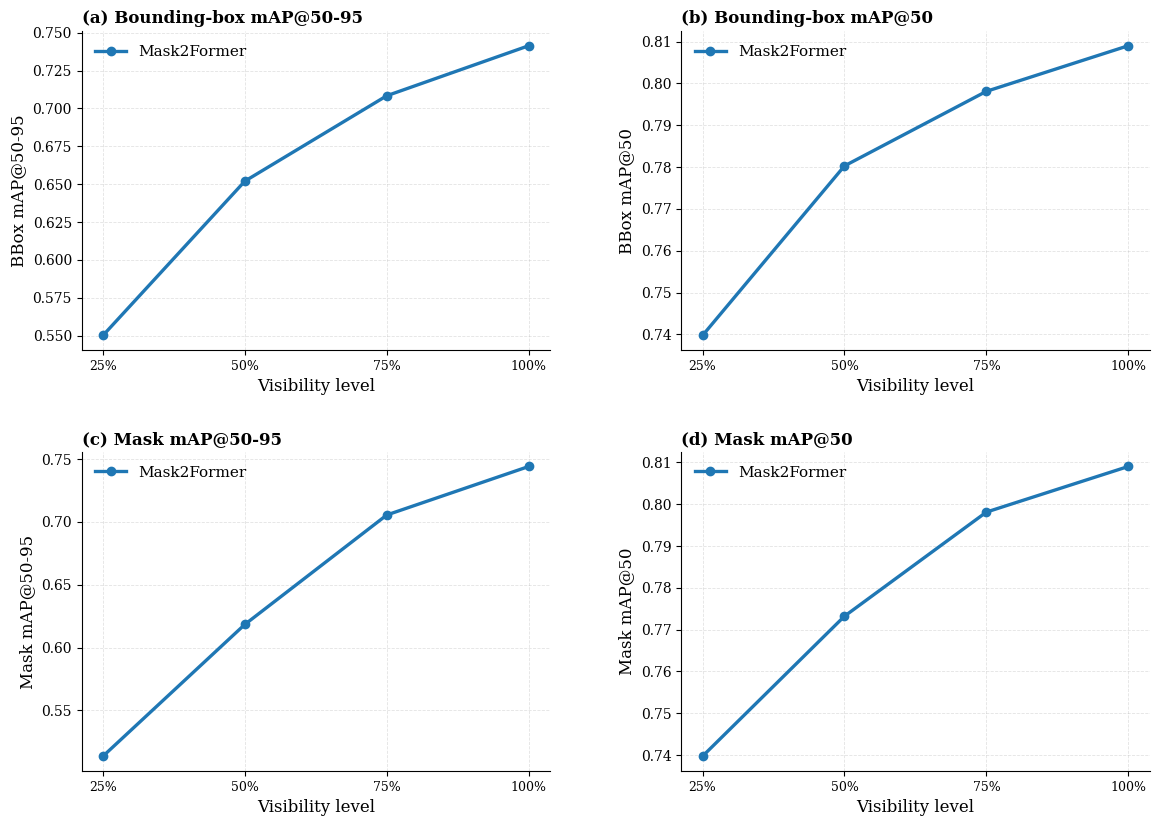

Guardado en:
C:\workspace\mmdetection\_visibility_plots\mask2former_visibility_metrics.png
C:\workspace\mmdetection\_visibility_plots\mask2former_visibility_metrics.pdf


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path(r"C:\workspace\mmdetection\mask2former_visibility_metrics.csv")
OUT_DIR = CSV_PATH.parent / "_visibility_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Normalizar nombres si vienen distinto
df = df.rename(columns={
    "coco/bbox_mAP": "bbox_mAP50_95",
    "coco/bbox_mAP_50": "bbox_mAP50",
    "coco/segm_mAP": "segm_mAP50_95",
    "coco/segm_mAP_50": "segm_mAP50",
})

visibility_order = ["25%", "50%", "75%", "100%"]
df["visibility"] = pd.Categorical(df["visibility"], categories=visibility_order, ordered=True)
df = df.sort_values(["visibility"])

metrics = [
    ("bbox_mAP50_95", "(a) Bounding-box mAP@50-95", "BBox mAP@50-95"),
    ("bbox_mAP50", "(b) Bounding-box mAP@50", "BBox mAP@50"),
    ("segm_mAP50_95", "(c) Mask mAP@50-95", "Mask mAP@50-95"),
    ("segm_mAP50", "(d) Mask mAP@50", "Mask mAP@50"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
axes = axes.ravel()

for ax, (metric, title, ylabel) in zip(axes, metrics):
    ax.plot(
        df["visibility"].astype(str),
        df[metric],
        marker="o",
        linewidth=2.4,
        label="Mask2Former"
    )

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Visibility level")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

fig.subplots_adjust(left=0.08, right=0.97, top=0.95, bottom=0.08, wspace=0.28, hspace=0.32)

png_path = OUT_DIR / "mask2former_visibility_metrics.png"
pdf_path = OUT_DIR / "mask2former_visibility_metrics.pdf"

fig.savefig(png_path, dpi=600, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Guardado en:")
print(png_path)
print(pdf_path)

In [41]:
import re
import pickle
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


# =========================================================
# CONFIG
# =========================================================

MMDET_ROOT = Path(r"C:\workspace\mmdetection")

CONFIG_BASE = MMDET_ROOT / "configs/mask2former/mask2former_fruits_visibility.py"
WEIGHTS_DIR = MMDET_ROOT / "work_dirs/mask2former_fruits_r50_50e_v1"

COCO_ROOT = Path(
    r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset"
)

OUT_DIR = MMDET_ROOT / "mask2former_visibility_epoch_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VIS_LEVELS = ["25", "50", "75", "100"]

# Tu caso: 61200 iter / 50 epochs = 1224
ITERS_PER_EPOCH = 1224

# evaluar solo cada N épocas para no hacerlo eterno
EVAL_EVERY_EPOCH = 5


# =========================================================
# AUXILIARES
# =========================================================

def get_iter_from_ckpt(path):
    m = re.search(r"iter_(\d+)", path.name)
    if m:
        return int(m.group(1))
    return None


def make_temp_config(level):
    cfg_path = OUT_DIR / f"temp_vis_{level}.py"

    text = f"""
_base_ = r'{CONFIG_BASE.as_posix()}'

VIS_LEVEL = "{level}"

data_root = r'{COCO_ROOT.as_posix()}'
ann_file = f'annotations/instances_val_{{VIS_LEVEL}}.json'

classes = (
    'apple_green',
    'apple_red',
    'peach',
    'avocado',
    'pear',
    'orange',
)

val_dataloader = dict(
    batch_size=1,
    num_workers=0,
    persistent_workers=False,
    drop_last=False,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(
        type='CocoDataset',
        metainfo=dict(classes=classes),
        data_root=data_root,
        ann_file=ann_file,
        data_prefix=dict(img=''),
        test_mode=True,
    )
)

test_dataloader = val_dataloader

val_evaluator = dict(
    type='CocoMetric',
    ann_file=data_root + '/' + ann_file,
    metric=['bbox', 'segm'],
    format_only=False
)

test_evaluator = val_evaluator

work_dir = r'{(OUT_DIR / f"work_vis_{level}").as_posix()}'
"""
    cfg_path.write_text(text, encoding="utf-8")
    return cfg_path


def evaluate_coco_from_pkl(pkl_path, gt_file):
    coco_gt = COCO(str(gt_file))
    valid_img_ids = set(coco_gt.getImgIds())

    cat_ids = sorted(coco_gt.getCatIds())
    label_to_cat_id = {i: cat_id for i, cat_id in enumerate(cat_ids)}

    with open(pkl_path, "rb") as f:
        preds = pickle.load(f)

    bbox_results = []
    segm_results = []

    for item in preds:
        img_id = int(item["img_id"])

        if img_id not in valid_img_ids:
            continue

        pred = item["pred_instances"]

        bboxes = np.asarray(pred["bboxes"])
        scores = np.asarray(pred["scores"])
        labels = np.asarray(pred["labels"]).astype(int)

        masks = pred.get("masks", None)

        for i in range(len(bboxes)):
            x1, y1, x2, y2 = bboxes[i]
            label = int(labels[i])
            cat_id = int(label_to_cat_id[label])
            score = float(scores[i])

            bbox_results.append({
                "image_id": img_id,
                "category_id": cat_id,
                "bbox": [
                    float(x1),
                    float(y1),
                    float(x2 - x1),
                    float(y2 - y1),
                ],
                "score": score,
            })

            if masks is not None:
                rle = masks[i]

                if isinstance(rle, dict):
                    if isinstance(rle["counts"], bytes):
                        rle["counts"] = rle["counts"].decode("utf-8")

                    segm_results.append({
                        "image_id": img_id,
                        "category_id": cat_id,
                        "segmentation": rle,
                        "score": score,
                    })

    # BBOX
    coco_dt_bbox = coco_gt.loadRes(bbox_results)
    eval_bbox = COCOeval(coco_gt, coco_dt_bbox, "bbox")
    eval_bbox.evaluate()
    eval_bbox.accumulate()
    eval_bbox.summarize()

    # SEGM
    coco_dt_segm = coco_gt.loadRes(segm_results)
    eval_segm = COCOeval(coco_gt, coco_dt_segm, "segm")
    eval_segm.evaluate()
    eval_segm.accumulate()
    eval_segm.summarize()

    return {
        "bbox_mAP50_95": eval_bbox.stats[0],
        "bbox_mAP50": eval_bbox.stats[1],
        "bbox_mAP75": eval_bbox.stats[2],
        "segm_mAP50_95": eval_segm.stats[0],
        "segm_mAP50": eval_segm.stats[1],
        "segm_mAP75": eval_segm.stats[2],
    }


# =========================================================
# CHECKPOINTS
# =========================================================

ckpts = sorted(WEIGHTS_DIR.glob("iter_*.pth"), key=lambda p: get_iter_from_ckpt(p) or 0)

selected_ckpts = []

for ckpt in ckpts:
    it = get_iter_from_ckpt(ckpt)
    if it is None:
        continue

    epoch = it / ITERS_PER_EPOCH

    if abs(epoch % EVAL_EVERY_EPOCH) < 1e-6:
        selected_ckpts.append((ckpt, it, epoch))

print("Checkpoints seleccionados:")
for ckpt, it, epoch in selected_ckpts:
    print(f"iter={it} | epoch={epoch:.0f} | {ckpt.name}")


# =========================================================
# EVALUACIÓN
# =========================================================

rows = []

for ckpt, it, epoch in selected_ckpts:
    for level in VIS_LEVELS:
        print(f"\nEvaluando epoch {epoch:.0f} | visibilidad {level}%")

        cfg = make_temp_config(level)

        out_pkl = OUT_DIR / f"preds_epoch_{int(epoch):03d}_vis_{level}.pkl"

        cmd = [
            "python",
            "tools/test.py",
            str(cfg),
            str(ckpt),
            "--out",
            str(out_pkl),
        ]

        result = subprocess.run(
            cmd,
            cwd=str(MMDET_ROOT),
            text=True,
            capture_output=True,
        )

        if result.returncode != 0:
            print("ERROR:")
            print(result.stderr)
            continue

        gt_file = COCO_ROOT / "annotations" / f"instances_val_{level}.json"
        metrics = evaluate_coco_from_pkl(out_pkl, gt_file)

        row = {
            "model": "Mask2Former",
            "iter": it,
            "epoch": epoch,
            "visibility": f"{level}%",
            **metrics,
        }

        rows.append(row)

        df_tmp = pd.DataFrame(rows)
        df_tmp.to_csv(OUT_DIR / "mask2former_visibility_by_epoch.csv", index=False, encoding="utf-8-sig")


df = pd.DataFrame(rows)
csv_path = OUT_DIR / "mask2former_visibility_by_epoch.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"\nCSV final guardado en:\n{csv_path}")
print(df)

Checkpoints seleccionados:
iter=61200 | epoch=50 | iter_61200.pth

Evaluando epoch 50 | visibilidad 25%
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.12s).
Accumulating evaluation results...
DONE (t=0.10s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.550
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.740
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.647
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.743
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.571
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.502
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.742
 Average Recall     (AR) @[ IoU=0.50:0.95

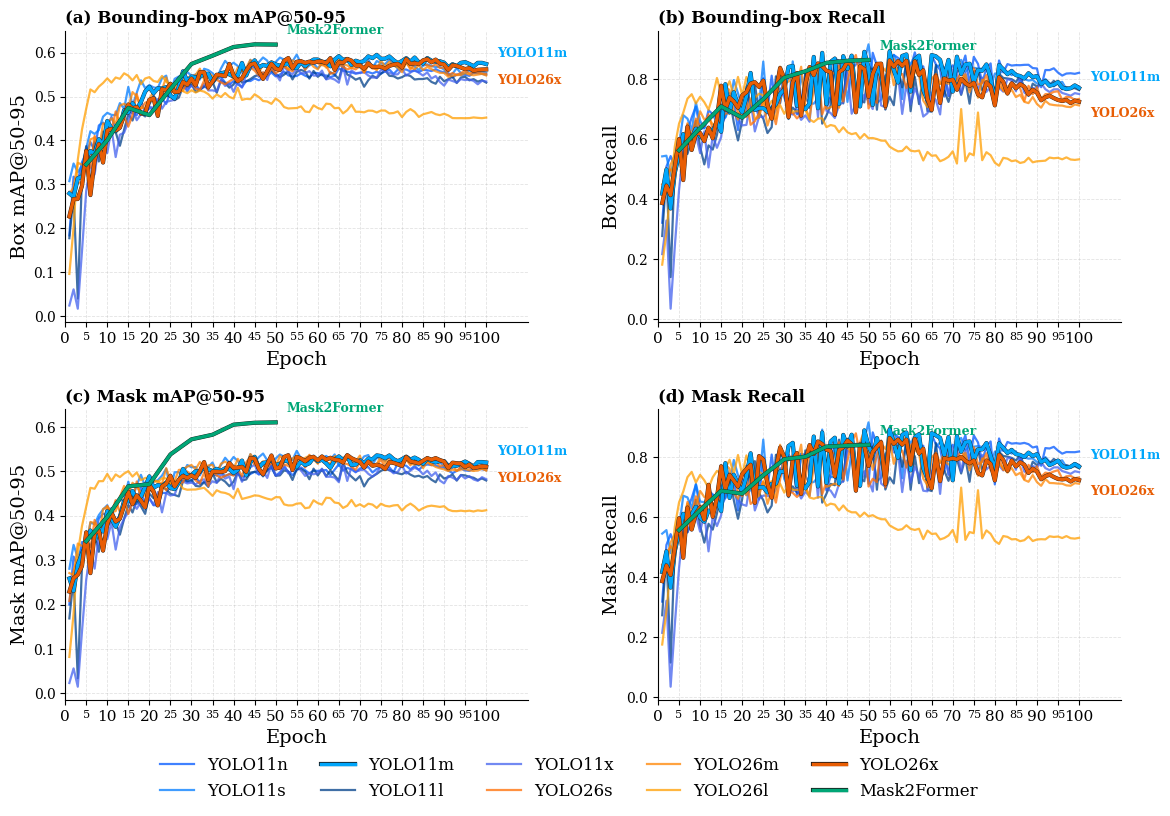

Figura guardada en PNG: C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_comparisons\all_models_curves_highlight_best.png
Figura guardada en PDF: C:\Users\garci\repos\Ultralytics\runs\segment\Manzana\_comparisons\all_models_curves_highlight_best.pdf


In [66]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# =========================================================
# CONFIG
# =========================================================
BASE_DIR = Path(r"C:\Users\garci\repos\Ultralytics\runs\segment\Manzana")
OUT_DIR = BASE_DIR / "_comparisons"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# Todos los modelos
RUNS = {
    "YOLO11n": {"type": "yolo", "path": BASE_DIR / "V11n_640"},
    "YOLO11s": {"type": "yolo", "path": BASE_DIR / "V11s_640"},
    "YOLO11m": {"type": "yolo", "path": BASE_DIR / "V11m_640"},
    "YOLO11l": {"type": "yolo", "path": BASE_DIR / "V11l_640"},
    "YOLO11x": {"type": "yolo", "path": BASE_DIR / "V11x_640"},

    "YOLO26s": {"type": "yolo", "path": BASE_DIR / "V26s_640"},
    "YOLO26m": {"type": "yolo", "path": BASE_DIR / "V26m_640"},
    "YOLO26l": {"type": "yolo", "path": BASE_DIR / "V26l_640"},
    "YOLO26x": {"type": "yolo", "path": BASE_DIR / "V26x_640"},

    "Mask2Former": {
        "type": "mmdet",
        "path": Path(r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\results.csv"),
    },
}


# Mejores modelos a destacar
# HIGHLIGHT_RUNS = {"YOLO11m", "YOLO26x"}
HIGHLIGHT_RUNS = {"YOLO11m", "YOLO26x", "Mask2Former"}
OUT_PNG = OUT_DIR / "all_models_curves_highlight_best.png"
OUT_PDF = OUT_DIR / "all_models_curves_highlight_best.pdf"

# =========================================================
# ESTILO GLOBAL
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,
    "figure.titlesize": 13,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# COLORES Y ESTILOS POR ARQUITECTURA
# =========================================================

def get_architecture(model_name: str):
    model_name = model_name.lower()

    if "yolo11" in model_name:
        return "YOLO11"
    elif "yolo26" in model_name:
        return "YOLO26"
    elif "mask2former" in model_name:
        return "Mask2Former"
    else:
        return "Other"


# =========================================================
# COLORES MÁS VIVOS POR ARQUITECTURA
# =========================================================

ARCH_COLORS = {
    "YOLO11": [
        "#0057FF",
        "#007BFF",
        "#00A6FB",
        "#003F88",
        "#4361EE",
    ],
    "YOLO26": [
        "#FF6D00",
        "#FF8500",
        "#FF9E00",
        "#E85D04",
        "#D00000",
    ],
    "Mask2Former": [
        "#00A676",
        "#06D6A0",
        "#2DC653",
        "#008000",
        "#38B000",
    ],
    "Other": [
        "#6C757D",
        "#343A40",
    ],
}

ARCH_MARKERS = {
    "YOLO11": "o",
    "YOLO26": "o",
    "Mask2Former": "o",
    "Other": "x",
}


def build_model_color_map():
    """
    Asigna colores vivos por arquitectura.
    Cada variante dentro de una arquitectura recibe un color distinto.
    """

    color_map = {}

    grouped_models = {
        "YOLO11": [m for m in RUNS.keys() if get_architecture(m) == "YOLO11"],
        "YOLO26": [m for m in RUNS.keys() if get_architecture(m) == "YOLO26"],
        "Mask2Former": [m for m in RUNS.keys() if get_architecture(m) == "Mask2Former"],
        "Other": [m for m in RUNS.keys() if get_architecture(m) == "Other"],
    }

    for arch, models in grouped_models.items():
        colors = ARCH_COLORS.get(arch, ARCH_COLORS["Other"])

        for i, model in enumerate(models):
            color_map[model] = colors[i % len(colors)]

    return color_map


BASE_COLORS = build_model_color_map()

# BASE_COLORS["Mask2Former"] = "#8338ec"

# ANNOT_OFFSETS["Mask2Former"] = (8, 10)

# offsets distintos para evitar superposición
ANNOT_OFFSETS = {
    "YOLO11m": (8, 8),
    "YOLO26x": (8, -8),
    "Mask2Former": (8, 10),
}

# =========================================================
# AUX
# =========================================================
def normalize_columns(df: pd.DataFrame):
    new_cols = {}
    for c in df.columns:
        c2 = c.strip().lower()
        c2 = c2.replace("/", "_").replace("(", "").replace(")", "")
        c2 = c2.replace(" ", "_").replace("-", "_").replace(".", "")
        while "__" in c2:
            c2 = c2.replace("__", "_")
        new_cols[c] = c2
    return df.rename(columns=new_cols)

import json
import numpy as np

##
def load_yolo_results(run_dir: Path):
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró {csv_path}")

    df = pd.read_csv(csv_path)
    df = normalize_columns(df)

    return pd.DataFrame({
        "epoch": df["epoch"],
        "box_map50_95": df["metrics_map50_95b"],
        "mask_map50_95": df["metrics_map50_95m"],
        "box_recall": df["metrics_recallb"],
        "mask_recall": df["metrics_recallm"],
    })


def load_mmdet_results(csv_path: Path):
    if not csv_path.exists():
        raise FileNotFoundError(f"No se encontró {csv_path}")

    df = pd.read_csv(csv_path)

    return pd.DataFrame({
        "epoch": df["epoch"],
        "box_map50_95": df["metrics/mAP50-95(B)"],
        "mask_map50_95": df["metrics/mAP50-95(M)"],
        "box_recall": df["metrics/recall(B)"],
        "mask_recall": df["metrics/recall(M)"],
    })


def load_results(run_info):
    if run_info["type"] == "yolo":
        return load_yolo_results(run_info["path"])

    if run_info["type"] == "mmdet":
        return load_mmdet_results(run_info["path"])

    raise ValueError(f"Tipo no soportado: {run_info['type']}")

###

def plot_metric(ax, metric_key, title, ylabel):
    xmax = 0

    for label, run_info in RUNS.items():
        data = load_results(run_info)

        if metric_key not in data.columns or data[metric_key].isna().all():
            continue

        data = data.dropna(subset=[metric_key])

        if data.empty:
            continue

        xmax = max(xmax, data["epoch"].max())

        is_highlight = label in HIGHLIGHT_RUNS
        color = BASE_COLORS.get(label)

        line, = ax.plot(
            data["epoch"],
            data[metric_key],
            label=label,
            color=color,
            linewidth=2.5 if is_highlight else 1.6,
            alpha=1.0 if is_highlight else 0.75,
            linestyle="-",
            zorder=5 if is_highlight else 2,
        )

        if is_highlight:
            line.set_path_effects([
                pe.Stroke(linewidth=3.0, foreground="#1A1A1A"),
                pe.Normal()
            ])

            x_last = data["epoch"].iloc[-1]
            y_last = data[metric_key].iloc[-1]

            dx, dy = ANNOT_OFFSETS.get(label, (8, 0))

            ax.annotate(
                label,
                (x_last, y_last),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left",
                va="center",
                fontsize=9,
                color=color,
                fontweight="bold",
                clip_on=False
            )

    ax.set_xlim(0, xmax + 10)
    ax.set_xticks(np.arange(0, xmax + 1, 5))
    for tick in ax.get_xticklabels():
        value = int(tick.get_text())

        if value % 10 == 5:
            tick.set_fontsize(8)   # ticks intermedios: 5, 15, 25, ...
        else:
            tick.set_fontsize(11)  # ticks principales: 0, 10, 20, ...
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, xmax + 10)

    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
# =========================================================
# FIGURA
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8.8))

plot_metric(axes[0, 0], "box_map50_95", "(a) Bounding-box mAP@50-95", "Box mAP@50-95")
plot_metric(axes[0, 1], "box_recall", "(b) Bounding-box Recall", "Box Recall")
plot_metric(axes[1, 0], "mask_map50_95", "(c) Mask mAP@50-95", "Mask mAP@50-95")
plot_metric(axes[1, 1], "mask_recall", "(d) Mask Recall", "Mask Recall")

# =========================================================
# LEYENDA GLOBAL ABAJO
# =========================================================
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

# fig.suptitle(
#     "Validation curves for all evaluated models with highlighted best-performing configurations",
#     y=0.98
# )

# ajustar espacios manualmente
fig.subplots_adjust(
    left=0.08,
    right=0.96,
    top=0.90,
    bottom=0.14,
    wspace=0.28,
    hspace=0.30
)

# =========================================================
# GUARDAR
# =========================================================
fig.savefig(OUT_PNG, dpi=600, bbox_inches="tight")
fig.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print(f"Figura guardada en PNG: {OUT_PNG}")
print(f"Figura guardada en PDF: {OUT_PDF}")

In [9]:
import re
import pickle
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


# =========================================================
# CONFIG
# =========================================================

MMDET_ROOT = Path(r"C:\workspace\mmdetection")

CONFIG = MMDET_ROOT / "configs/mask2former/mask2former_fruits_r50.py"

WORK_DIR = MMDET_ROOT / "work_dirs/mask2former_fruits_r50_50e_v2_epoch_ckpts"

COCO_GT = Path(
    r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val.json"
)

OUT_DIR = WORK_DIR / "_results_csv"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = WORK_DIR / "results.csv"

# evaluar checkpoints cada 5 épocas
CKPT_PATTERN = "epoch_*.pth"


# =========================================================
# AUXILIARES
# =========================================================

def get_epoch(path):
    m = re.search(r"epoch_(\d+)", path.name)
    return int(m.group(1)) if m else None


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def evaluate_from_pkl(pkl_path, gt_file):
    coco_gt = COCO(str(gt_file))
    valid_img_ids = set(coco_gt.getImgIds())

    cat_ids = sorted(coco_gt.getCatIds())
    label_to_cat_id = {i: cat_id for i, cat_id in enumerate(cat_ids)}

    with open(pkl_path, "rb") as f:
        preds = pickle.load(f)

    bbox_results = []
    segm_results = []

    for item in preds:
        img_id = int(item["img_id"])

        if img_id not in valid_img_ids:
            continue

        pred = item["pred_instances"]

        bboxes = to_numpy(pred["bboxes"])
        scores = to_numpy(pred["scores"])
        labels = to_numpy(pred["labels"]).astype(int)

        masks = pred.get("masks", None)

        for i in range(len(bboxes)):
            x1, y1, x2, y2 = bboxes[i]
            label = int(labels[i])

            if label not in label_to_cat_id:
                continue

            cat_id = int(label_to_cat_id[label])
            score = float(scores[i])

            bbox_results.append({
                "image_id": img_id,
                "category_id": cat_id,
                "bbox": [
                    float(x1),
                    float(y1),
                    float(x2 - x1),
                    float(y2 - y1),
                ],
                "score": score,
            })

            if masks is not None:
                rle = masks[i]

                if isinstance(rle, dict):
                    if isinstance(rle["counts"], bytes):
                        rle["counts"] = rle["counts"].decode("utf-8")

                    segm_results.append({
                        "image_id": img_id,
                        "category_id": cat_id,
                        "segmentation": rle,
                        "score": score,
                    })

    # -------------------------
    # BBOX COCOeval
    # -------------------------
    coco_dt_bbox = coco_gt.loadRes(bbox_results)
    eval_bbox = COCOeval(coco_gt, coco_dt_bbox, "bbox")
    eval_bbox.evaluate()
    eval_bbox.accumulate()
    eval_bbox.summarize()

    # -------------------------
    # SEGM COCOeval
    # -------------------------
    coco_dt_segm = coco_gt.loadRes(segm_results)
    eval_segm = COCOeval(coco_gt, coco_dt_segm, "segm")
    eval_segm.evaluate()
    eval_segm.accumulate()
    eval_segm.summarize()

    # COCO stats:
    # stats[0] = AP50-95
    # stats[1] = AP50
    # stats[2] = AP75
    # stats[8] = AR maxDets=100
    bbox_map = float(eval_bbox.stats[0])
    bbox_map50 = float(eval_bbox.stats[1])
    bbox_map75 = float(eval_bbox.stats[2])
    bbox_recall = float(eval_bbox.stats[8])

    segm_map = float(eval_segm.stats[0])
    segm_map50 = float(eval_segm.stats[1])
    segm_map75 = float(eval_segm.stats[2])
    segm_recall = float(eval_segm.stats[8])

    # Precision aproximada promedio desde COCOeval
    bbox_precision = float(np.nanmean(eval_bbox.eval["precision"][eval_bbox.eval["precision"] > -1]))
    segm_precision = float(np.nanmean(eval_segm.eval["precision"][eval_segm.eval["precision"] > -1]))

    bbox_f1 = 2 * bbox_precision * bbox_recall / (bbox_precision + bbox_recall + 1e-9)
    segm_f1 = 2 * segm_precision * segm_recall / (segm_precision + segm_recall + 1e-9)

    return {
        "metrics/precision(B)": bbox_precision,
        "metrics/recall(B)": bbox_recall,
        "metrics/mAP50(B)": bbox_map50,
        "metrics/mAP50-95(B)": bbox_map,
        "metrics/mAP75(B)": bbox_map75,
        "metrics/F1(B)": bbox_f1,

        "metrics/precision(M)": segm_precision,
        "metrics/recall(M)": segm_recall,
        "metrics/mAP50(M)": segm_map50,
        "metrics/mAP50-95(M)": segm_map,
        "metrics/mAP75(M)": segm_map75,
        "metrics/F1(M)": segm_f1,
    }


# =========================================================
# MAIN
# =========================================================

ckpts = sorted(
    WORK_DIR.glob(CKPT_PATTERN),
    key=lambda p: get_epoch(p) if get_epoch(p) is not None else 999999
)

rows = []

for ckpt in ckpts:
    epoch = get_epoch(ckpt)

    if epoch is None:
        continue

    print(f"\n==============================")
    print(f"Evaluando epoch {epoch}")
    print(f"Checkpoint: {ckpt}")
    print(f"==============================")

    out_pkl = OUT_DIR / f"preds_epoch_{epoch}.pkl"

    if not out_pkl.exists():
        cmd = [
            "python",
            "tools/test.py",
            str(CONFIG),
            str(ckpt),
            "--out",
            str(out_pkl),
        ]

        result = subprocess.run(
            cmd,
            cwd=str(MMDET_ROOT),
            text=True,
            capture_output=True,
        )

        if result.returncode != 0:
            print("ERROR en tools/test.py")
            print(result.stderr)
            continue

    metrics = evaluate_from_pkl(out_pkl, COCO_GT)

    row = {
        "epoch": epoch,
        **metrics,
    }

    rows.append(row)

    df_tmp = pd.DataFrame(rows).sort_values("epoch")
    df_tmp.to_csv(RESULTS_CSV, index=False, encoding="utf-8-sig")

df = pd.DataFrame(rows).sort_values("epoch")
df.to_csv(RESULTS_CSV, index=False, encoding="utf-8-sig")

print(f"\nCSV guardado en:")
print(RESULTS_CSV)
print(df)


Evaluando epoch 5
Checkpoint: C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\epoch_5.pth
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.59s).
Accumulating evaluation results...
DONE (t=0.38s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.345
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.432
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.365
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.239
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.368
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.333
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.526
 Average Recall     (AR) 

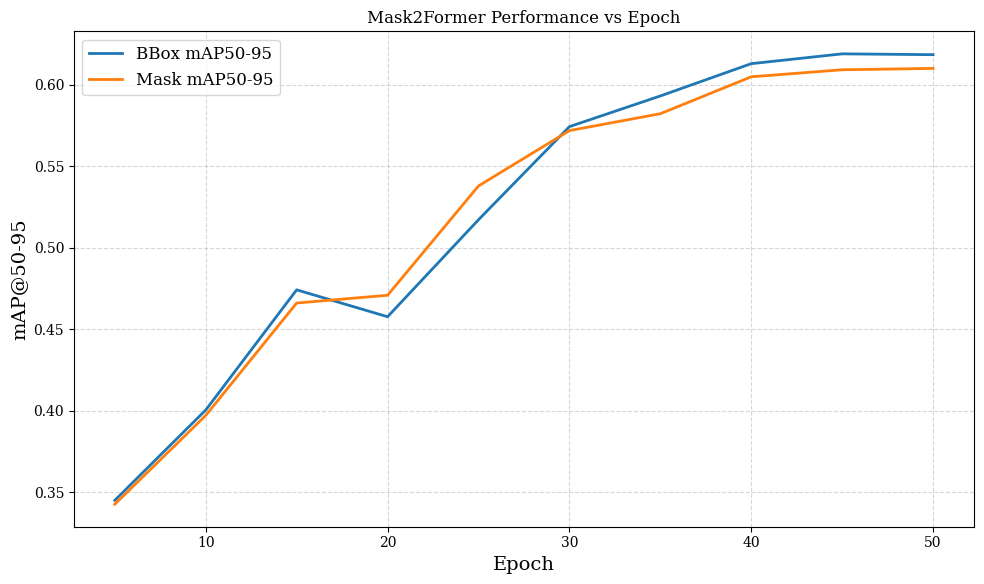

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# cargar CSV
df = pd.read_csv("C:/workspace/mmdetection/work_dirs/mask2former_fruits_r50_50e_v2_epoch_ckpts/results.csv")

# ordenar por epoch
df = df.sort_values("epoch")

# ================================
# GRAFICO TIPO YOLO
# ================================
plt.figure(figsize=(10,6))

plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="BBox mAP50-95", linewidth=2)
plt.plot(df["epoch"], df["metrics/mAP50-95(M)"], label="Mask mAP50-95", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("mAP@50-95")
plt.title("Mask2Former Performance vs Epoch")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig("mask2former_training_curve.png", dpi=300)
plt.show()

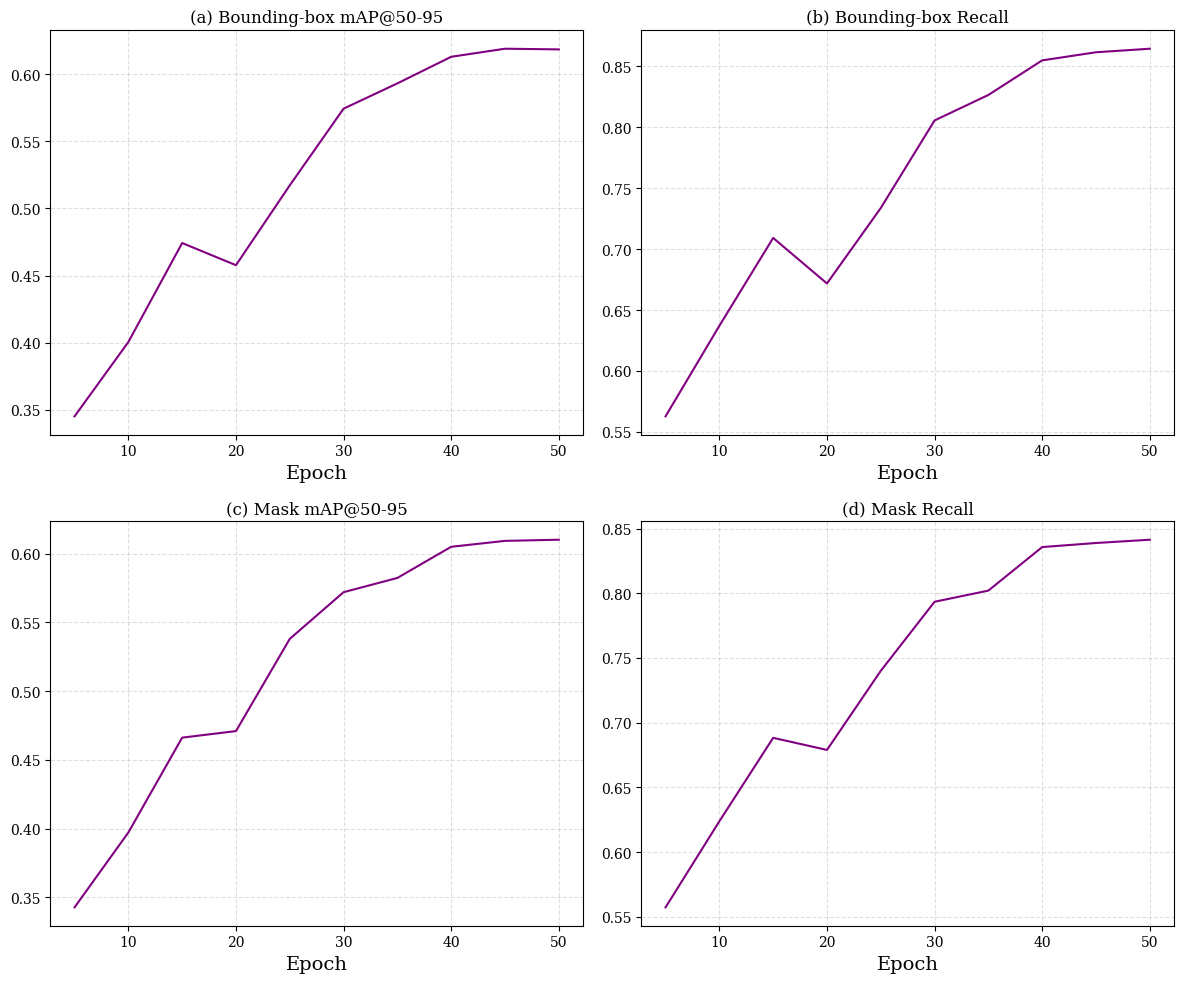

In [4]:
fig, axs = plt.subplots(2,2, figsize=(12,10))

# (a) bbox mAP
axs[0,0].plot(df["epoch"], df["metrics/mAP50-95(B)"], color="purple")
axs[0,0].set_title("(a) Bounding-box mAP@50-95")

# (b) bbox recall
axs[0,1].plot(df["epoch"], df["metrics/recall(B)"], color="purple")
axs[0,1].set_title("(b) Bounding-box Recall")

# (c) mask mAP
axs[1,0].plot(df["epoch"], df["metrics/mAP50-95(M)"], color="purple")
axs[1,0].set_title("(c) Mask mAP@50-95")

# (d) mask recall
axs[1,1].plot(df["epoch"], df["metrics/recall(M)"], color="purple")
axs[1,1].set_title("(d) Mask Recall")

for ax in axs.flat:
    ax.set_xlabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mask2former_full_metrics.png", dpi=300)
plt.show()

In [10]:
from pathlib import Path
import pandas as pd
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# =========================================================
# PATHS
# =========================================================

GT_JSON = r"C:\Users\garci\OneDrive - UNIVERSIDAD ANDRES BELLO\Desktop\1.Universidad\PhdDISA\vision\Transformer\Manzana\coco_dataset\annotations\instances_val.json"

BBOX_JSON = r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\preds_bbox.json"

SEGM_JSON = r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\preds_segm.json"

# =========================================================
# LOAD COCO
# =========================================================

coco_gt = COCO(GT_JSON)

# =========================================================
# EVALUAR BBOX
# =========================================================

coco_dt_bbox = coco_gt.loadRes(BBOX_JSON)

eval_bbox = COCOeval(coco_gt, coco_dt_bbox, "bbox")
eval_bbox.evaluate()
eval_bbox.accumulate()
eval_bbox.summarize()

bbox_map = eval_bbox.stats[0]
bbox_map50 = eval_bbox.stats[1]
bbox_recall = eval_bbox.stats[8]

# aproximación precision usando AP50
bbox_precision = bbox_map50

bbox_f1 = (
    2 * bbox_precision * bbox_recall /
    (bbox_precision + bbox_recall + 1e-9)
)

# =========================================================
# EVALUAR SEGM
# =========================================================

coco_dt_segm = coco_gt.loadRes(SEGM_JSON)

eval_segm = COCOeval(coco_gt, coco_dt_segm, "segm")
eval_segm.evaluate()
eval_segm.accumulate()
eval_segm.summarize()

segm_map = eval_segm.stats[0]
segm_map50 = eval_segm.stats[1]
segm_recall = eval_segm.stats[8]

# aproximación precision usando AP50
segm_precision = segm_map50

segm_f1 = (
    2 * segm_precision * segm_recall /
    (segm_precision + segm_recall + 1e-9)
)

# =========================================================
# TABLA FINAL
# =========================================================

df = pd.DataFrame([{
    "Model": "Mask2Former",
    "Var.": "R50",

    "mAP50-95 (B)": round(bbox_map * 100, 2),
    "mAP50 (B)": round(bbox_map50 * 100, 2),
    "Prec (B)": round(bbox_precision * 100, 2),
    "Rec (B)": round(bbox_recall * 100, 2),
    "F1 (B)": round(bbox_f1 * 100, 2),

    "mAP50-95 (M)": round(segm_map * 100, 2),
    "mAP50 (M)": round(segm_map50 * 100, 2),
    "Prec (M)": round(segm_precision * 100, 2),
    "Rec (M)": round(segm_recall * 100, 2),
    "F1 (M)": round(segm_f1 * 100, 2),
}])

print(df)

# =========================================================
# GUARDAR CSV
# =========================================================

out_csv = Path("mask2former_final_metrics.csv")

df.to_csv(out_csv, index=False)

print(f"\nCSV guardado en: {out_csv}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\workspace\\mmdetection\\work_dirs\\mask2former_fruits_r50_50e_v2_epoch_ckpts\\preds_bbox.json'

In [11]:
from pathlib import Path
import pandas as pd

CSV_PATH = Path(
    r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\results.csv"
)

df = pd.read_csv(CSV_PATH)

# tomar la mejor época según máscara mAP50-95
best = df.loc[df["metrics/mAP50-95(M)"].idxmax()]

row = {
    "Model": "Mask2Former",
    "Var.": "R50",

    "mAP50-95 (B)": best["metrics/mAP50-95(B)"] * 100,
    "mAP50-95 (M)": best["metrics/mAP50-95(M)"] * 100,

    "Prec (B)": best["metrics/precision(B)"] * 100,
    "Rec (B)": best["metrics/recall(B)"] * 100,
    "F1 (B)": best["metrics/F1(B)"] * 100,

    "Prec (M)": best["metrics/precision(M)"] * 100,
    "Rec (M)": best["metrics/recall(M)"] * 100,
    "F1 (M)": best["metrics/F1(M)"] * 100,
}

df_final = pd.DataFrame([row]).round(2)

print(df_final.to_string(index=False))

      Model Var.  mAP50-95 (B)  mAP50-95 (M)  Prec (B)  Rec (B)  F1 (B)  Prec (M)  Rec (M)  F1 (M)
Mask2Former  R50         61.85         61.01     63.83    86.44   73.44     61.87    84.14    71.3


In [12]:
from pathlib import Path
import pandas as pd

RESULTS_CSV = Path(r"C:\workspace\mmdetection\work_dirs\mask2former_fruits_r50_50e_v2_epoch_ckpts\results.csv")

df = pd.read_csv(RESULTS_CSV)

# Mejor época según máscara mAP50-95
best = df.loc[df["metrics/mAP50-95(M)"].idxmax()]

row = {
    "Model": "Mask2Former",
    "Var.": "R50",
    "mAP50-95 (B)": best["metrics/mAP50-95(B)"] * 100,
    "mAP50-95 (M)": best["metrics/mAP50-95(M)"] * 100,
}

print(pd.DataFrame([row]).round(2))

         Model Var.  mAP50-95 (B)  mAP50-95 (M)
0  Mask2Former  R50         61.85         61.01


In [13]:
CPU_MS = 0.0      # reemplazar
PARAMS_M = 0.0    # reemplazar
FLOPS_B = 0.0     # reemplazar

final = pd.DataFrame([{
    "Model": "Mask2Former",
    "Var.": "R50",
    "mAP50-95 (B)": best["metrics/mAP50-95(B)"] * 100,
    "mAP50-95 (M)": best["metrics/mAP50-95(M)"] * 100,
    "CPU (ms)": CPU_MS,
    "Params (M)": PARAMS_M,
    "FLOPs (B)": FLOPS_B,
}]).round(2)

print(final.to_string(index=False))
print(final.to_latex(index=False, escape=False))

      Model Var.  mAP50-95 (B)  mAP50-95 (M)  CPU (ms)  Params (M)  FLOPs (B)
Mask2Former  R50         61.85         61.01       0.0         0.0        0.0
\begin{tabular}{llrrrrr}
\toprule
Model & Var. & mAP50-95 (B) & mAP50-95 (M) & CPU (ms) & Params (M) & FLOPs (B) \\
\midrule
Mask2Former & R50 & 61.850000 & 61.010000 & 0.000000 & 0.000000 & 0.000000 \\
\bottomrule
\end{tabular}



In [16]:
from mmengine.analysis import get_model_complexity_info
from mmengine.config import Config
from mmdet.registry import MODELS
from mmdet.utils import register_all_modules

# =========================================================
# REGISTRAR MÓDULOS DE MMDETECTION
# =========================================================
register_all_modules(init_default_scope=True)

# =========================================================
# CONFIG
# =========================================================
cfg_path = r"C:\workspace\mmdetection\configs\mask2former\mask2former_fruits_r50.py"

cfg = Config.fromfile(cfg_path)

# =========================================================
# CONSTRUIR MODELO
# =========================================================
model = MODELS.build(cfg.model)
model.eval()

# =========================================================
# CALCULAR COMPLEJIDAD
# =========================================================
result = get_model_complexity_info(
    model,
    input_shape=(3, 640, 640),
    show_table=False,
    show_arch=False
)

print(result)
print("FLOPs:", result["flops_str"])
print("Params:", result["params_str"])

{'flops': 103125694400.0, 'flops_str': '0.103T', 'activations': 261283800, 'activations_str': '0.261G', 'params': 44004359, 'params_str': '44.004M', 'out_table': '', 'out_arch': ''}
FLOPs: 0.103T
Params: 44.004M
